## Low regret strategies for the use of biomass in the European energy transition
### Master's Thesis Oliver Keller 2024

### Preparation
Use the julia code which can be found under https://github.com/oliver-keller/EuSysMod to create the scenarios you want and run the optimization model. The outputsOfInterest.csv file contains the different usage categories in the different columns and the iterations in the rows. This file must be copied into the DECIDE directory to run this script.

Now import all the needed libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist, euclidean
from tabulate import tabulate
import os

from utilities.produce_interpretable_tree import produce_interpretable_tree

Next we read in the data and specify/create an output directory

In [2]:
# df_input = pd.read_csv("data/outputsOfInterest.csv", sep=",") # Read the CSV file
df_input = pd.read_csv(r"C:\Users\olive\Desktop\Projects\EuSysMod\results\V1.2\initial\merged_outputsOfInterest.csv", sep=",") # Read the CSV file
df_input = df_input.drop(columns=['iteration']) # Drop the iteration column
df_input= df_input.abs() # Take the absolute value of all columns

folder = "./results/"
if not os.path.exists(folder): # Create the folder if it does not exist
    os.makedirs(folder)

## combine categories
df_input['LTH'] = df_input['LTH'] + df_input['DH'] + df_input['SpaceHeating'] # Combine 'LTH', 'DH', and 'SpaceHeating' columns
df_input = df_input.drop(columns=['DH', 'SpaceHeating']) # Drop the original 'DH' and 'SpaceHeating' columns
df_input['HTH'] = df_input['MTH'] + df_input['HTH'] # Combine 'MTH' and 'HTH' 
df_input = df_input.drop(columns=['MTH']) # Drop the original 'DH' and 'SpaceHeating' columns




df_input

,crudeOil,HVC,CHP,LTH,HTH,rawBiogas,syngas,coal
0,763.747731,0.778222,0.000035,0.000033,0.000042,0.000602,0.000000,0.000082
1,312.248961,476.997861,0.000000,0.000025,0.000000,0.000236,0.000000,0.000000
2,44.538034,0.000385,0.000291,0.001467,82.622310,23.287683,0.000333,0.000597
3,133.512980,0.000083,0.000000,0.000302,2.828780,1.062046,0.000000,0.000103
4,815.671824,1.970035,0.000000,0.000000,0.000000,0.000113,0.000000,0.000000
...,...,...,...,...,...,...,...,...
995,424.839873,578.415636,0.000000,0.000011,0.000000,0.000137,0.000000,0.000000
996,756.747318,41.686315,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
997,814.368812,187.175222,0.000000,0.000000,0.000000,0.000078,0.000000,0.000000
998,783.039065,233.621143,0.000045,0.000068,0.802602,0.000519,0.000000,0.000208


Now we create a visualization of the data in a table showing the maximum and minimum of each category. 
Next the categories with low biomass usage (below 10% of highest max value) are filtered out and a spiderplot is created showing the biomass usage of the relevant categories.

In [3]:
## Create a taple with the max and min values of each column
# Calculate the max and min values for each column
data_max = df_input.max().values
data_min = df_input.min().values

# Create a list of lists with column name, max value, and min value
table_data = []
for column in df_input.columns:
    max_value = df_input[column].max()
    min_value = df_input[column].min()
    table_data.append([column, max_value, min_value])

# Print the table
print(tabulate(table_data, headers=["Column Name", "Max Value", "Min Value"], tablefmt="grid"))

+---------------+---------------+-------------+
| Column Name   |     Max Value |   Min Value |
+===============+===============+=============+
| crudeOil      | 978.745       |     1.77331 |
+---------------+---------------+-------------+
| HVC           | 621.491       |     0       |
+---------------+---------------+-------------+
| CHP           |   0.00102235  |     0       |
+---------------+---------------+-------------+
| LTH           | 260.589       |     0       |
+---------------+---------------+-------------+
| HTH           | 612.102       |     0       |
+---------------+---------------+-------------+
| rawBiogas     | 111.272       |     0       |
+---------------+---------------+-------------+
| syngas        |   0.000468281 |     0       |
+---------------+---------------+-------------+
| coal          |  76.4971      |     0       |
+---------------+---------------+-------------+


In [4]:
## Filter not relevant columns
# Filter the columns with higher max_value than 10% of the highest max_value
highest_max_value = max(data_max)
filtered_columns = [column for column, max_value, _ in table_data if max_value > 0.05 * highest_max_value]

# Remove the columns with too low values
df_filtered = df_input[filtered_columns]

In [5]:
# DIMENSIONS = ['Oil', 'Chemicals', 'Low-T Heat', 'High-T Heat', 'Biogas', 'Coal']
DIMENSIONS = ['Oil', 'HVC', 'LTH', 'HTH', 'Biogas', 'Coal']
 
# DIMENSIONS = ['crudeOil', 'HVC', 'LTH', 'HTH', 'biogas', 'coal']

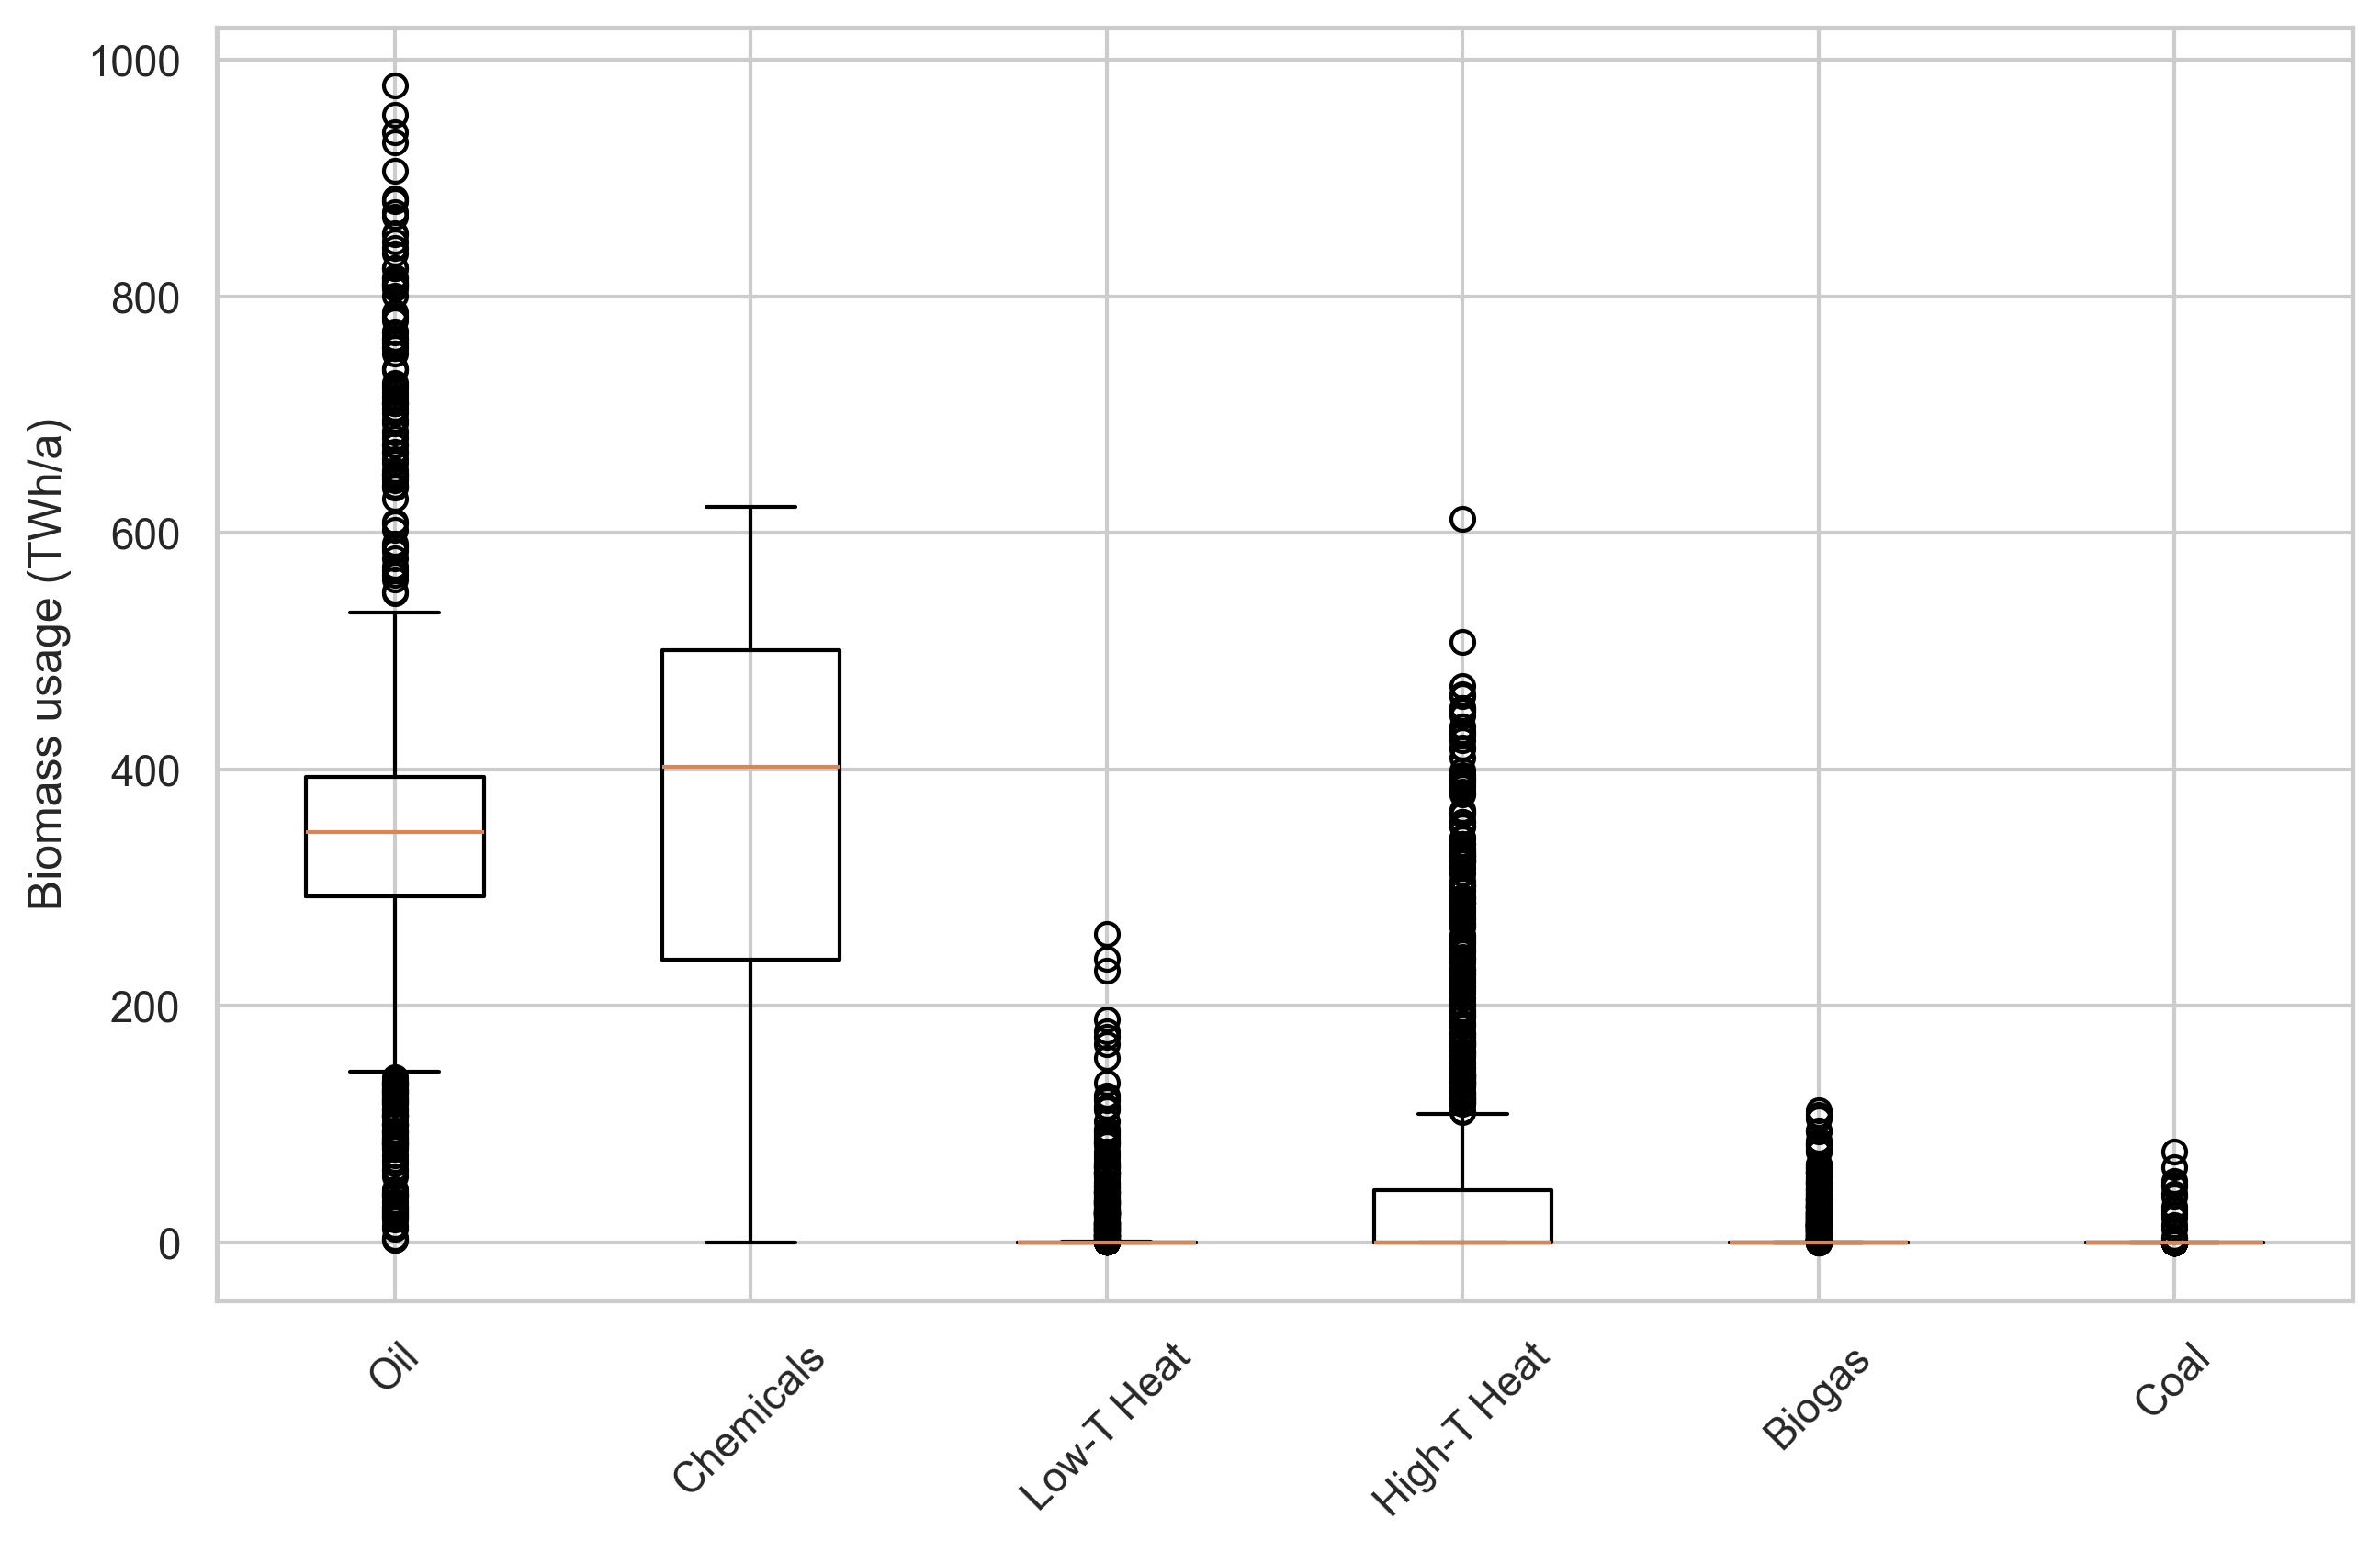

In [6]:
# Create a boxplot
plt.figure(figsize=(10, 6), dpi=300)
plt.boxplot(df_filtered.values)
# The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers.

# Set the x-axis tick labels
plt.xticks(range(1, len(df_filtered.columns) + 1), DIMENSIONS, rotation=45)

# Set the y-axis label
plt.ylabel('Biomass usage (TWh/a)')

# Set the title
# plt.title('Biomass usage by the different categories')

# Show the plot
plt.show()

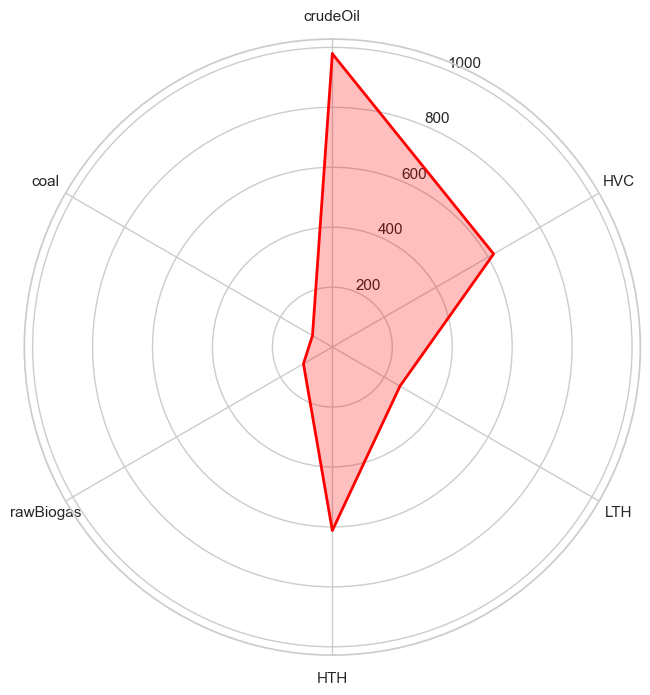

In [7]:
## Create a radar plot showing the max and min values of the relevant columns
# Calculate the max and min values for each column
data_max_filtered = df_filtered.max().values
data_min_filtered = df_filtered.min().values

# Number of variables
num_vars = len(df_filtered.columns)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

# Initialize the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw one axe per variable + add labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], df_filtered.columns)

# Plot data
values_max = data_max_filtered.tolist()
values_max += values_max[:1]
ax.plot(angles, values_max, color='red', linewidth=2, linestyle='solid', label='Max')

values_min = data_min_filtered.tolist()
values_min += values_min[:1]
ax.plot(angles, values_min, color='blue', linewidth=2, linestyle='solid', label='Min')

# Fill area
ax.fill(angles, values_max, color='red', alpha=0.25)
ax.fill(angles, values_min, color='blue', alpha=0.25)

# Add a title
# plt.title('Spider Plot of Max and Min Values', size=20, color='k', y=1.1)

# Show the plot
plt.show()


If you want to normalize the data before the clustering this can be dine with the next cell. I recommend not normalizing the values because it stretches the space and the clusering algorithm does not see the real distances between the scenarios.

In [8]:
"""
# Normalize each column
for column in df_filtered.columns:
    max_value = df_filtered[column].max()
    df_filtered[column] = df_filtered[column] / max_value
"""

'\n# Normalize each column\nfor column in df_filtered.columns:\n    max_value = df_filtered[column].max()\n    df_filtered[column] = df_filtered[column] / max_value\n'

In [9]:
# Print and save the filtered dataframe which will be used as input for the clustering
print(df_filtered)
# df_filtered.to_csv(folder+"df_filtered.csv",sep=";", index=False)

       crudeOil         HVC       LTH         HTH  rawBiogas      coal
0    763.747731    0.778222  0.000033    0.000042   0.000602  0.000082
1    312.248961  476.997861  0.000025    0.000000   0.000236  0.000000
2     44.538034    0.000385  0.001467   82.622310  23.287683  0.000597
3    133.512980    0.000083  0.000302    2.828780   1.062046  0.000103
4    815.671824    1.970035  0.000000    0.000000   0.000113  0.000000
..          ...         ...       ...         ...        ...       ...
995  424.839873  578.415636  0.000011    0.000000   0.000137  0.000000
996  756.747318   41.686315  0.000000    0.000000   0.000000  0.000000
997  814.368812  187.175222  0.000000    0.000000   0.000078  0.000000
998  783.039065  233.621143  0.000068    0.802602   0.000519  0.000208
999  202.169691  234.861735  0.000130  195.066364   0.004980  0.000095

[1000 rows x 6 columns]


# Clustering

Define main parameter

In [10]:
NUMBER_OF_CLUSTERS = 3

Calculate the decision tree and save the dataframe with the cluster column added

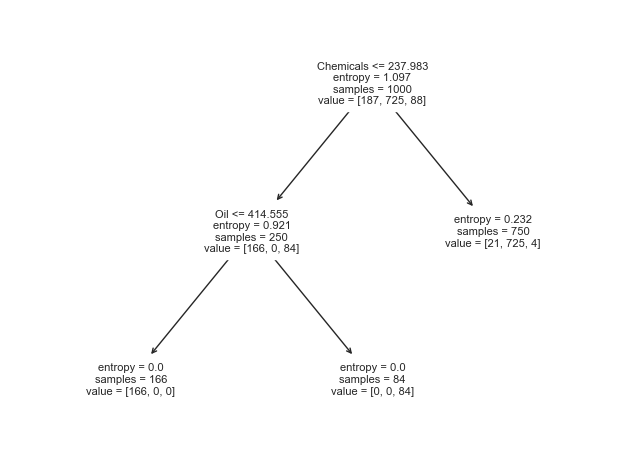

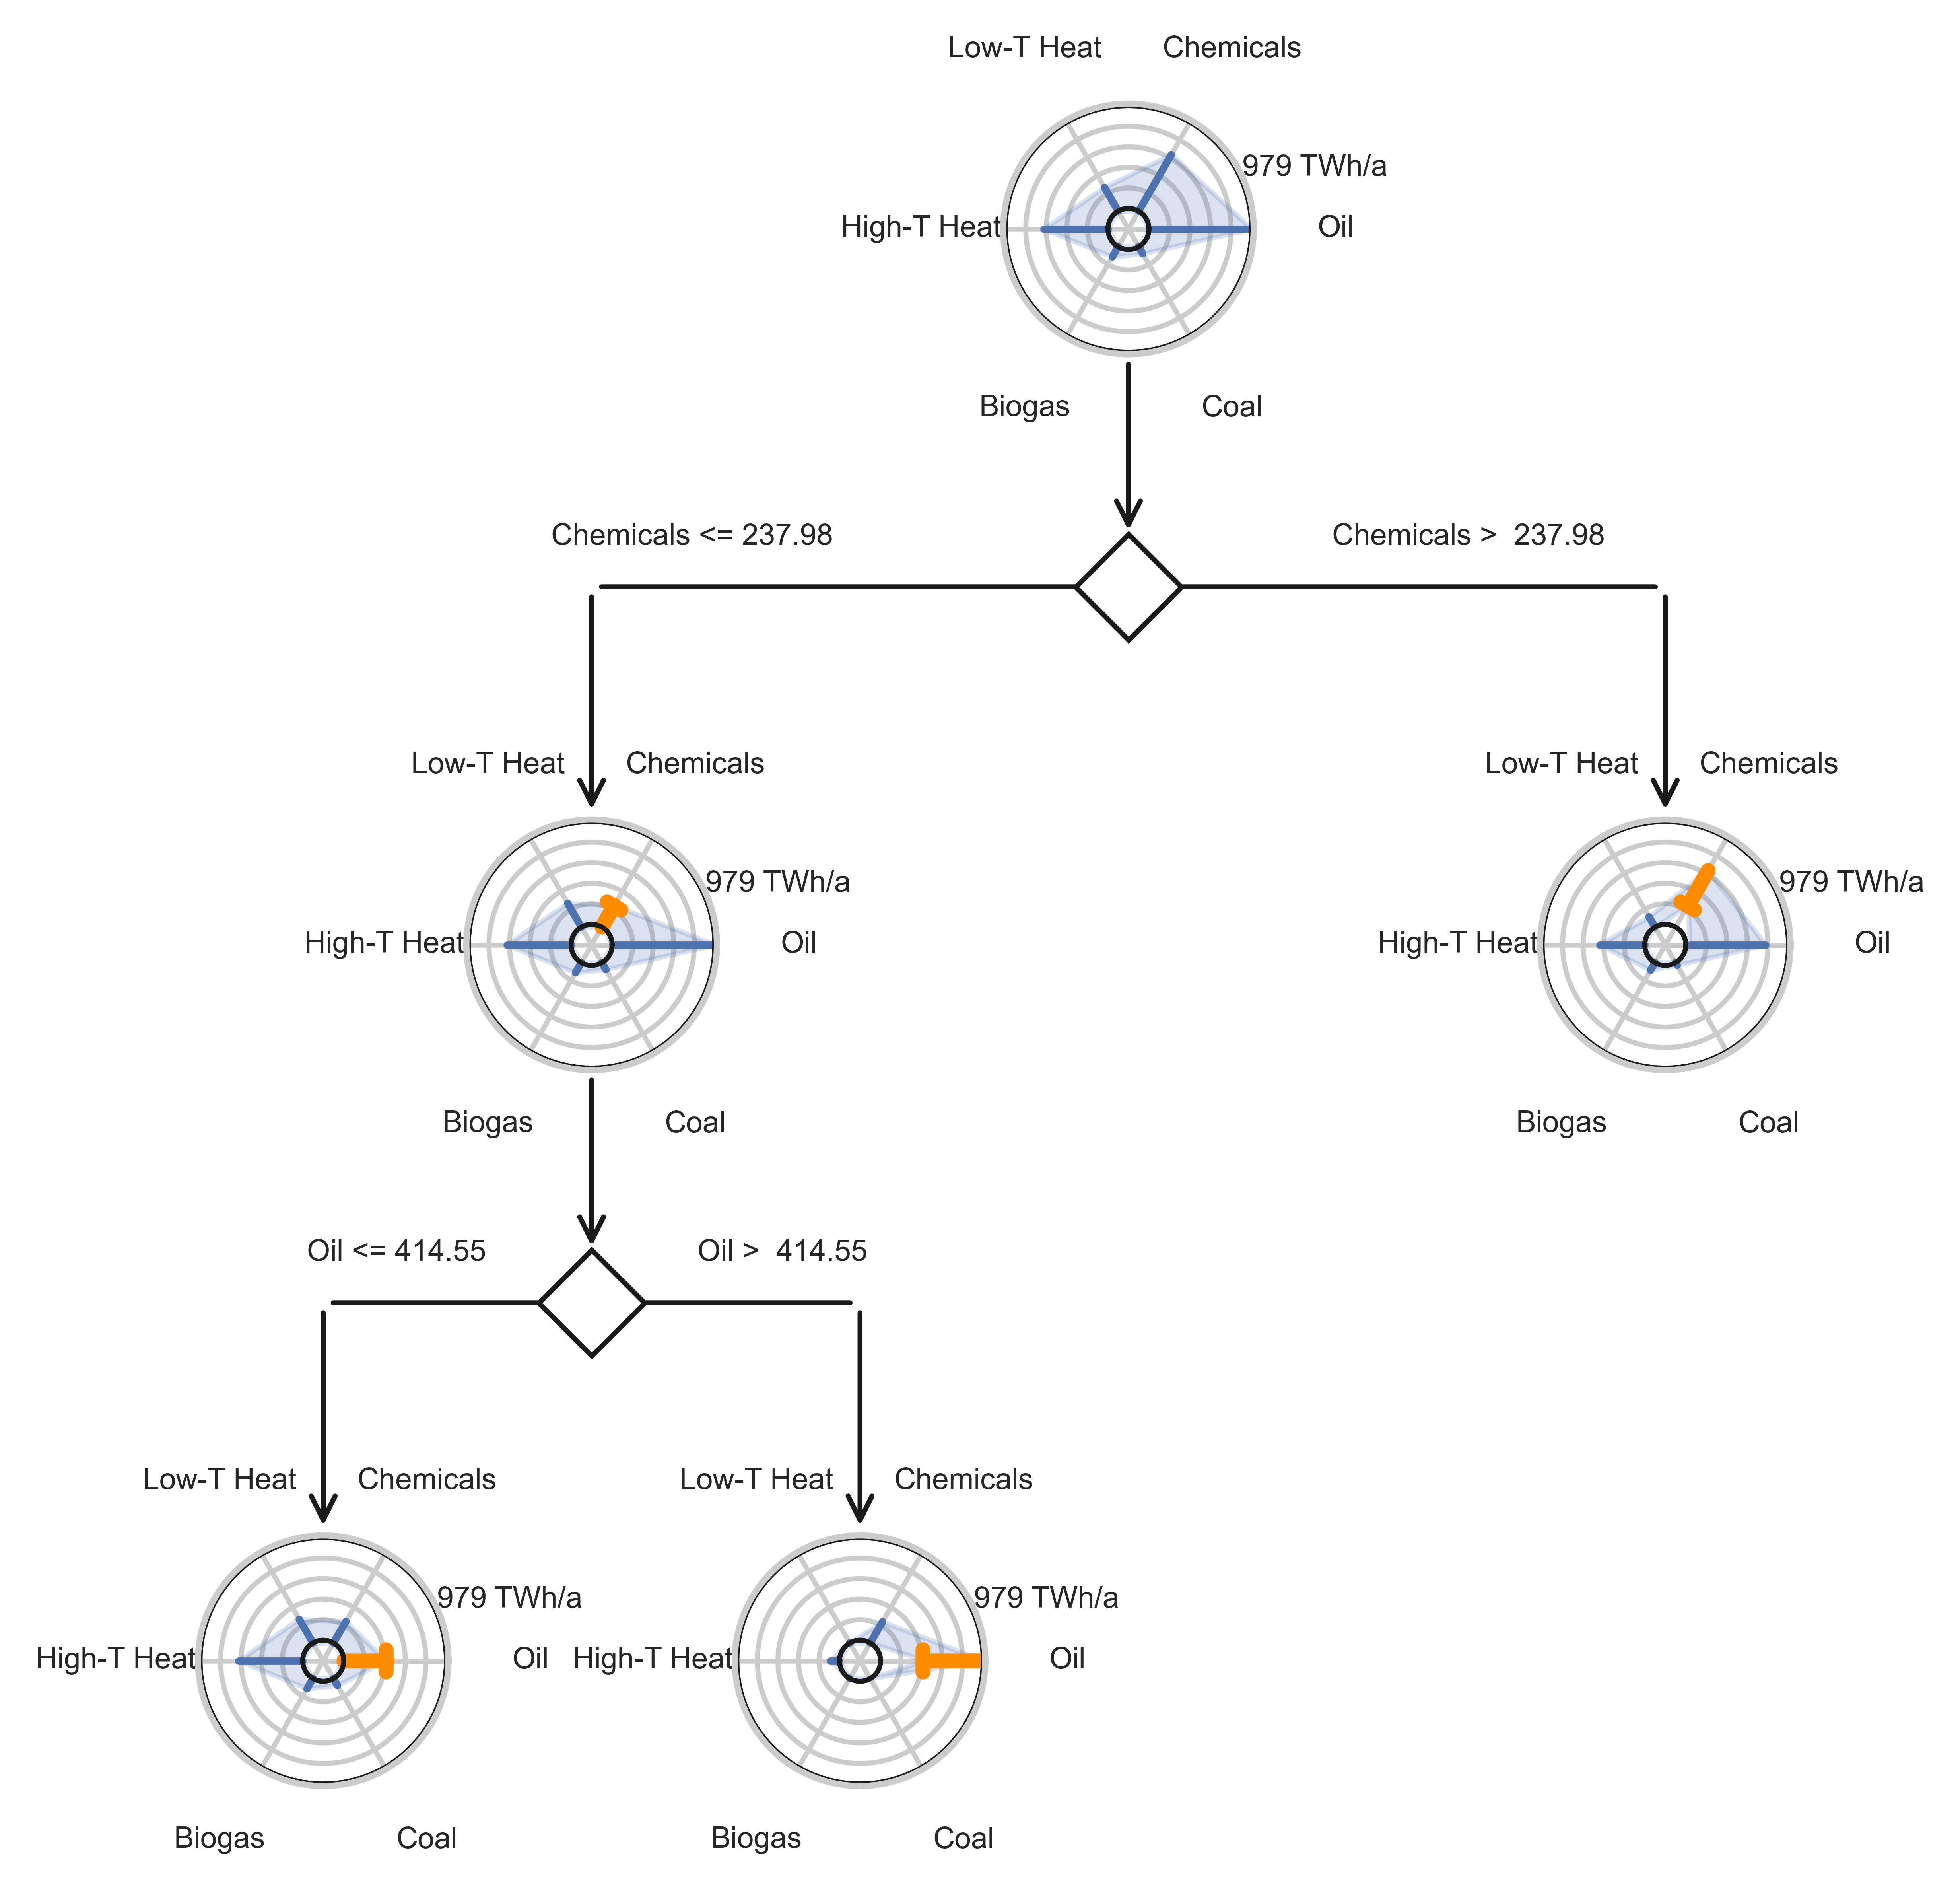

In [11]:

df_filtered_with_cluster, nodes, choices, decision_space = produce_interpretable_tree(df_filtered, DIMENSIONS, NUMBER_OF_CLUSTERS, plot_all_spyders=False, figure_folder=folder, tree_size=(6, 6), absolute_values=True, colors=['darkorange', 'darkorange', 'darkorange'], print_info=False)



Print the choices needed to do the regret calculation in EuSysMod

In [12]:
print(choices)

# cluster 0 = high HVC
# cluster 1 = high oil
# cluster 2 = high HTH

{0: [' Chemicals <= 237.98', ' Chemicals >  237.98'], 1: [' Oil <= 414.55', ' Oil >  414.55']}


Calculate the geometric median of each cluster

In [13]:
median_data = [] # List to store the results
dimensions = [dim for dim in list(df_filtered_with_cluster.columns) if "cluster" not in dim] # Extract the dimensions from the DataFrame

for cluster in range(NUMBER_OF_CLUSTERS):
    df_cluster = df_filtered_with_cluster[df_filtered_with_cluster['cluster_final'] == cluster] # Extract the points of the cluster

    # Extract the 3D points from the DataFrame
    points = df_cluster[dimensions].values

    # Calculate the pairwise distances between the points
    distances = cdist(points, points, metric='euclidean')

    # Calculate the sum of distances for each point
    sum_distances = np.sum(distances, axis=1)

    # Find the index of the point with the minimum sum of distances
    geometric_median_index = np.argmin(sum_distances)

    # Get the geometric median_df point
    geometric_median = points[geometric_median_index]

    # Find the index of the geometric median point in the original DataFrame
    index = np.where((df_filtered_with_cluster[dimensions[0]] == geometric_median[0]) & (df_filtered_with_cluster[dimensions[1]] == geometric_median[1]) & (df_filtered_with_cluster[dimensions[2]] == geometric_median[2]))[0][0] +1

    # Append the result to the median_data list
    median_data.append([cluster, index] + list(geometric_median))

# Create a DataFrame from the median_data list
column_names = ['cluster', 'index'] + dimensions
median_df = pd.DataFrame(median_data, columns=column_names)


print(median_df)


   cluster  index    crudeOil         HVC        LTH         HTH  rawBiogas  \
0        0    164  161.052074   43.493235  39.696257  244.830713  24.566363   
1        1    338  357.402460  450.842678   0.000013    0.000000   0.000201   
2        2    800  738.172570   43.272623   0.000000    0.000000   0.000120   

       coal  
0  0.000183  
1  0.000000  
2  0.000000  


# Plot the results

### Create a 3D scatter plot
That only makes sence if the filtered data contains 3 dimension

In [14]:

STRATEGY_NAMES = {1: 'Strategy HVC+', 2: 'Strategy HVC- oil+', 0: 'Strategy HVC- oil-'}
COLOR_MAP = {1: 'blue', 2: 'darkviolet', 0: 'darkgreen'}

# Map the 'cluster_final' column to the defined colors
COLORS = df_filtered_with_cluster['cluster_final'].map(COLOR_MAP)

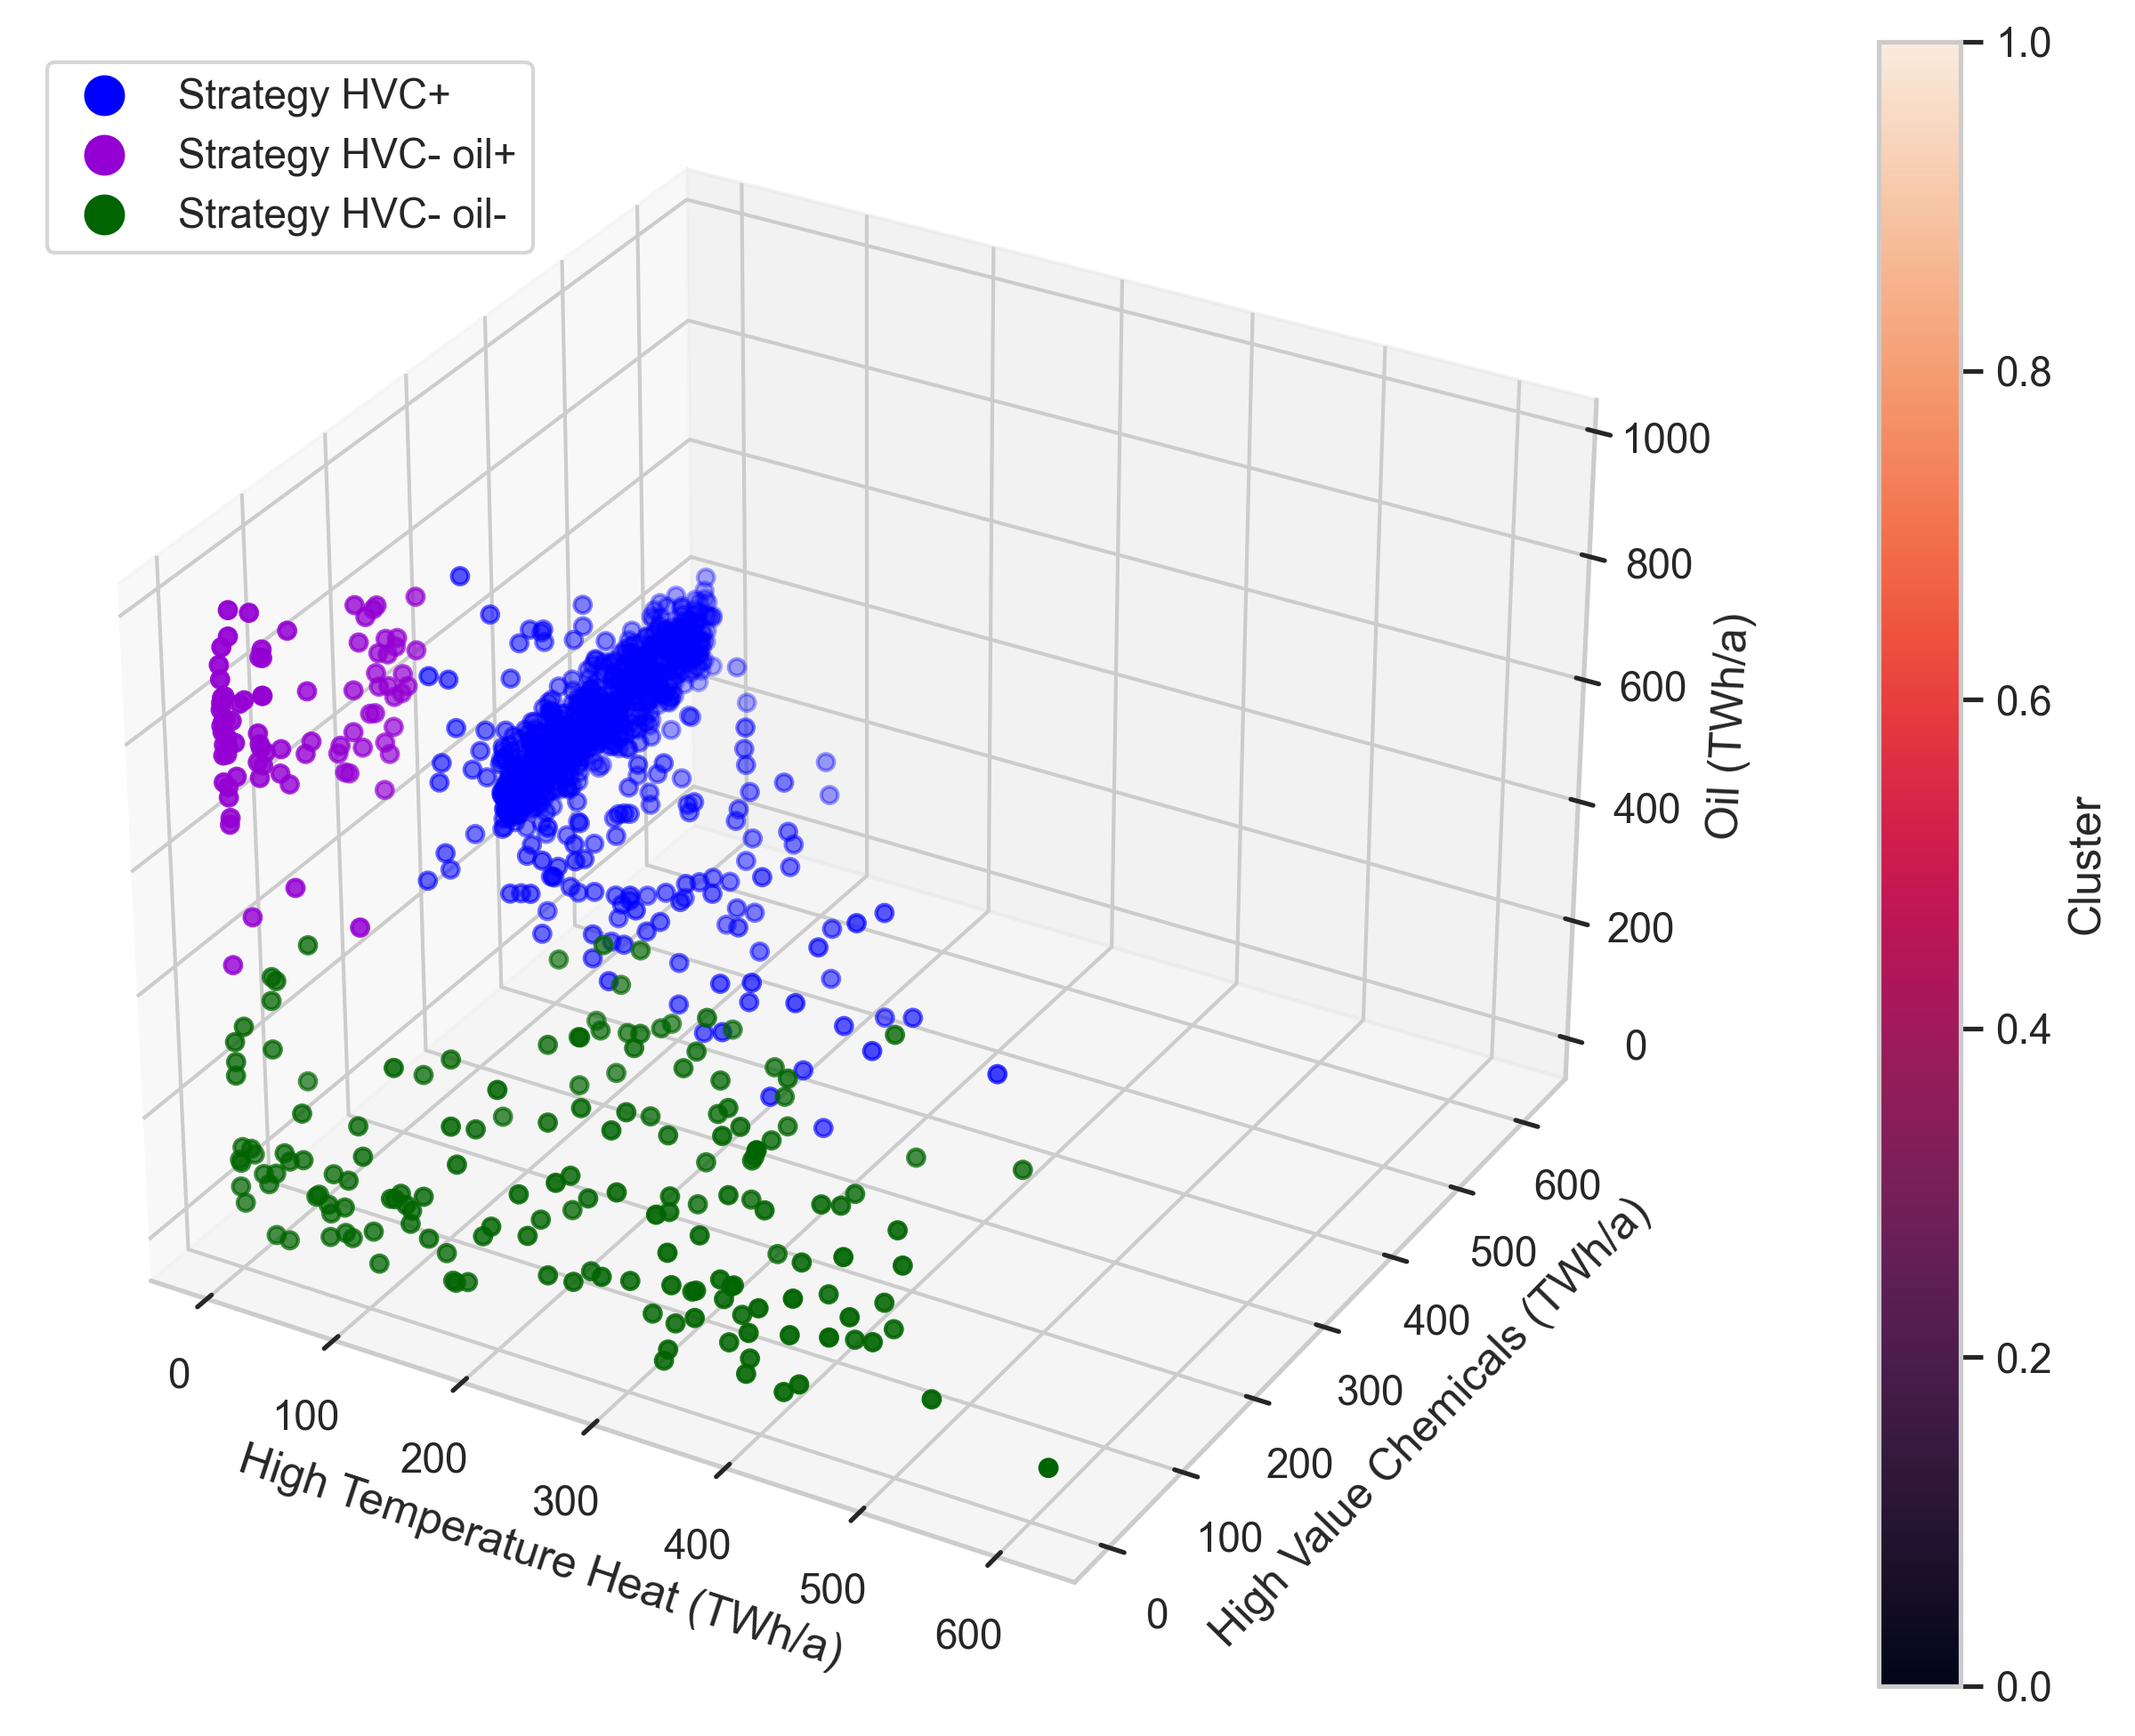

In [15]:
X_AXIS = 'HTH'
Y_AXIS = 'HVC'
Z_AXIS = 'crudeOil'

# Create a 3D scatter plot
fig = plt.figure(figsize=(20, 8), dpi=300)

ax = fig.add_subplot(111, projection='3d')


# Plot the dots
dots = ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], df_filtered_with_cluster[Z_AXIS], c=COLORS, zorder = 1)
# medians = ax.scatter(median_df[X_AXIS], median_df[Y_AXIS], median_df[Z_AXIS], c='red', alpha=1, s=50, zorder = 2)



# Define funcitons to plot the planes in the 3D space to show the decision tree splits
def plot_x_plane(ax, x_value, color='r', alpha=0.5):
    yy, zz = np.meshgrid(
        np.linspace(df_filtered_with_cluster[Y_AXIS].min(), df_filtered_with_cluster[Y_AXIS].max(), 10),
        np.linspace(df_filtered_with_cluster[Z_AXIS].min(), df_filtered_with_cluster[Z_AXIS].max(), 10)
    )
    xx = np.full(yy.shape, x_value)
    ax.plot_surface(xx, yy, zz, color=color, alpha=alpha, rstride=100, cstride=100)

def plot_y_plane(ax, y_value, color='r', alpha=0.5):
    xx, zz = np.meshgrid(
        np.linspace(df_filtered_with_cluster[X_AXIS].min(), df_filtered_with_cluster[X_AXIS].max(), 10),
        np.linspace(df_filtered_with_cluster[Z_AXIS].min(), df_filtered_with_cluster[Z_AXIS].max(), 10)
    )
    yy = np.full(xx.shape, y_value)
    ax.plot_surface(xx, yy, zz, color=color, alpha=alpha, rstride=100, cstride=100)

def plot_z_plane(ax, z_value, color='r', alpha=0.5):
    xx, yy = np.meshgrid(
        np.linspace(df_filtered_with_cluster[X_AXIS].min(), df_filtered_with_cluster[X_AXIS].max(), 10),
        # np.linspace(df_filtered_with_cluster[Y_AXIS].min(), df_filtered_with_cluster[Y_AXIS].max(), 10)
        np.linspace(0, 238, 10)
    )
    zz = np.full(xx.shape, z_value)
    ax.plot_surface(xx, yy, zz, color=color, alpha=alpha, rstride=100, cstride=100)
    
# Plot the decision tree split as planes
for cluster, choice in choices.items():
    for condition in choice:
        column, operator, value = condition.split()
        if column == X_AXIS:
            plot_x_plane(ax, x_value=float(value), color='r', alpha=0.2)
        elif column == Y_AXIS:
            plot_y_plane(ax, y_value=float(value), color='r', alpha=0.2)
        elif column == Z_AXIS:
            plot_z_plane(ax, z_value=float(value), color='r', alpha=0.2)


# Set labels and title
ax.set_xlabel('High Temperature Heat (TWh/a)')
ax.set_ylabel('High Value Chemicals (TWh/a)')
ax.set_zlabel('Oil (TWh/a)')
# ax.set_title('Biomass Usage', fontsize=20)
# ax.set_xlim(0)

# Add a colorbar
plt.colorbar(dots, ax=ax, label='Cluster') # just that the image is not cropped


# Create custom legend handles
handles = [
    mlines.Line2D([], [], color=COLOR_MAP[1], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[1]),
    mlines.Line2D([], [], color=COLOR_MAP[2], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[2]),
    mlines.Line2D([], [], color=COLOR_MAP[0], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[0]),
    # mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Geometric Median')
]

# Add the legend
ax.legend(handles=handles, loc='upper left')


plt.savefig("results/3D-tree.svg",  format="svg")
plt.savefig("results/3D-tree.pdf")

# Show the plot
plt.show()




## Create 2D cuts 

Define function

In [16]:
## Create a 2D side view plot
def create_2D_side_view_plot(df_filtered_with_cluster, median_df, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, X_AXIS, Y_AXIS, limits=False):
    fig = plt.figure(figsize=(7, 7), dpi=300)
    ax = fig.add_subplot(111)

    # Plot the side view (2D)
    dots = ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], c=COLORS, alpha=0.6)
    dots= ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], c='black', alpha=0.1)
    if type(median_df) == pd.DataFrame: median_df = ax.scatter(median_df[X_AXIS], median_df[Y_AXIS], c = 'red', alpha=0.9)
    


    # Plot the planes on the 2D side view
    for i, choice in choices.items():
        for condition in choice:
            column, operator, value = condition.split()
            value = float(value)
            if column == X_AXIS:
                ax.axvline(x=value, color='r', linestyle='--', alpha=0.5)
                # y_min, y_max =  0, 238  # range of y values
                # ax.plot([value, value], [y_min, y_max], color='r', linestyle='--', alpha=0.5)

            elif column == Y_AXIS:
                # ax.axhline(y=value, color='r', linestyle='--', alpha=0.5)
                x_min, x_max = 0, 238  # range of x values
                ax.plot([x_min, x_max], [value, value], color='r', linestyle='--', alpha=0.5)


    # Set labels and title for the 2D plot
    ax.set_xlabel('High Value Chemicals (TWh/a)')
    ax.set_ylabel('Oil (TWh/a)')
    #ax.set_ylabel(Y_AXIS)
    #ax.set_title('Biomass usage (2D cut)')

    # Create custom legend handles
    if type(median_df) != type(None):
        handles = [
            mlines.Line2D([], [], color=COLOR_MAP[1], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[1]),
            mlines.Line2D([], [], color=COLOR_MAP[2], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[2]),
            mlines.Line2D([], [], color=COLOR_MAP[0], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[0]),
            mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Geometric Median')
        ]
    else:
          handles = [
            mlines.Line2D([], [], color=COLOR_MAP[1], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[1]),
            mlines.Line2D([], [], color=COLOR_MAP[2], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[2]),
            mlines.Line2D([], [], color=COLOR_MAP[0], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[0]),
        ]

    # Add the legend
    ax.legend(handles=handles, loc='upper right')

    # define range of the plot
    if limits:
        ax.set_xlim(-30, 650)
        ax.set_ylim(-50, 1030)


    plt.savefig(f"results/2D-tree_{X_AXIS}_{Y_AXIS}.svg",  format="svg")
    plt.savefig(f"results/2D-tree_{X_AXIS}_{Y_AXIS}.pdf")

    # Show the plots
    plt.show()


Create 2D plots

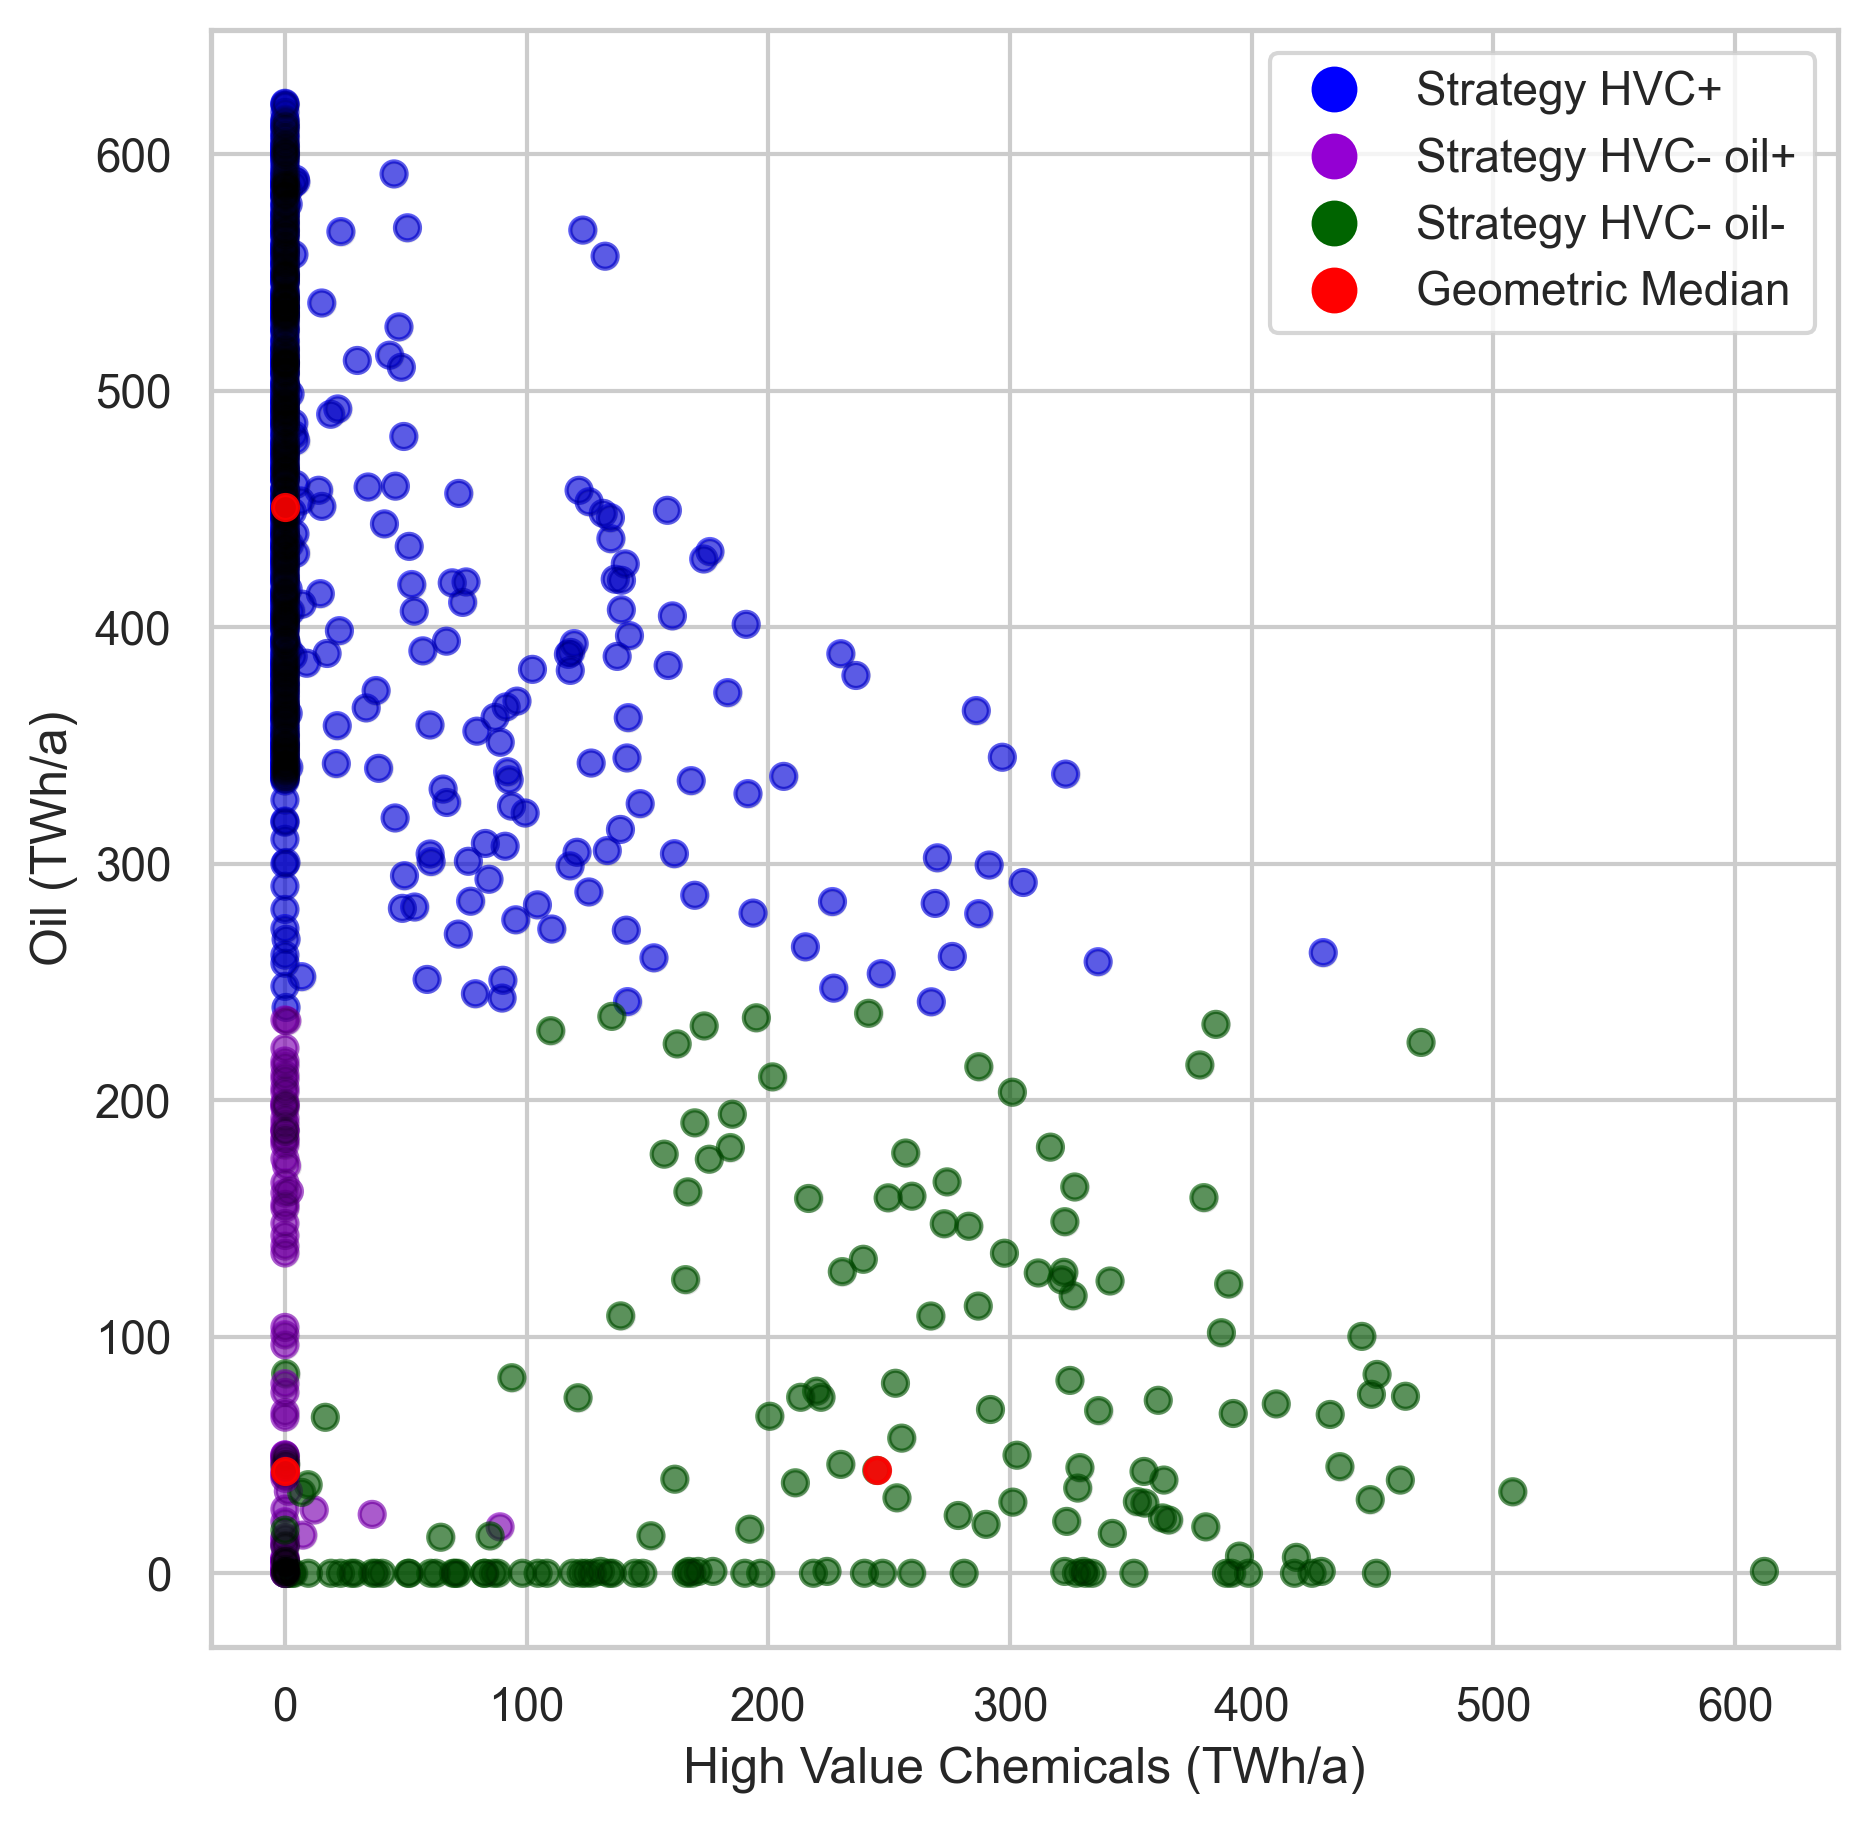

In [17]:
# Specify cut plane
X_AXIS = 'HTH'
Y_AXIS = 'HVC'


create_2D_side_view_plot(df_filtered_with_cluster, median_df, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, X_AXIS, Y_AXIS)

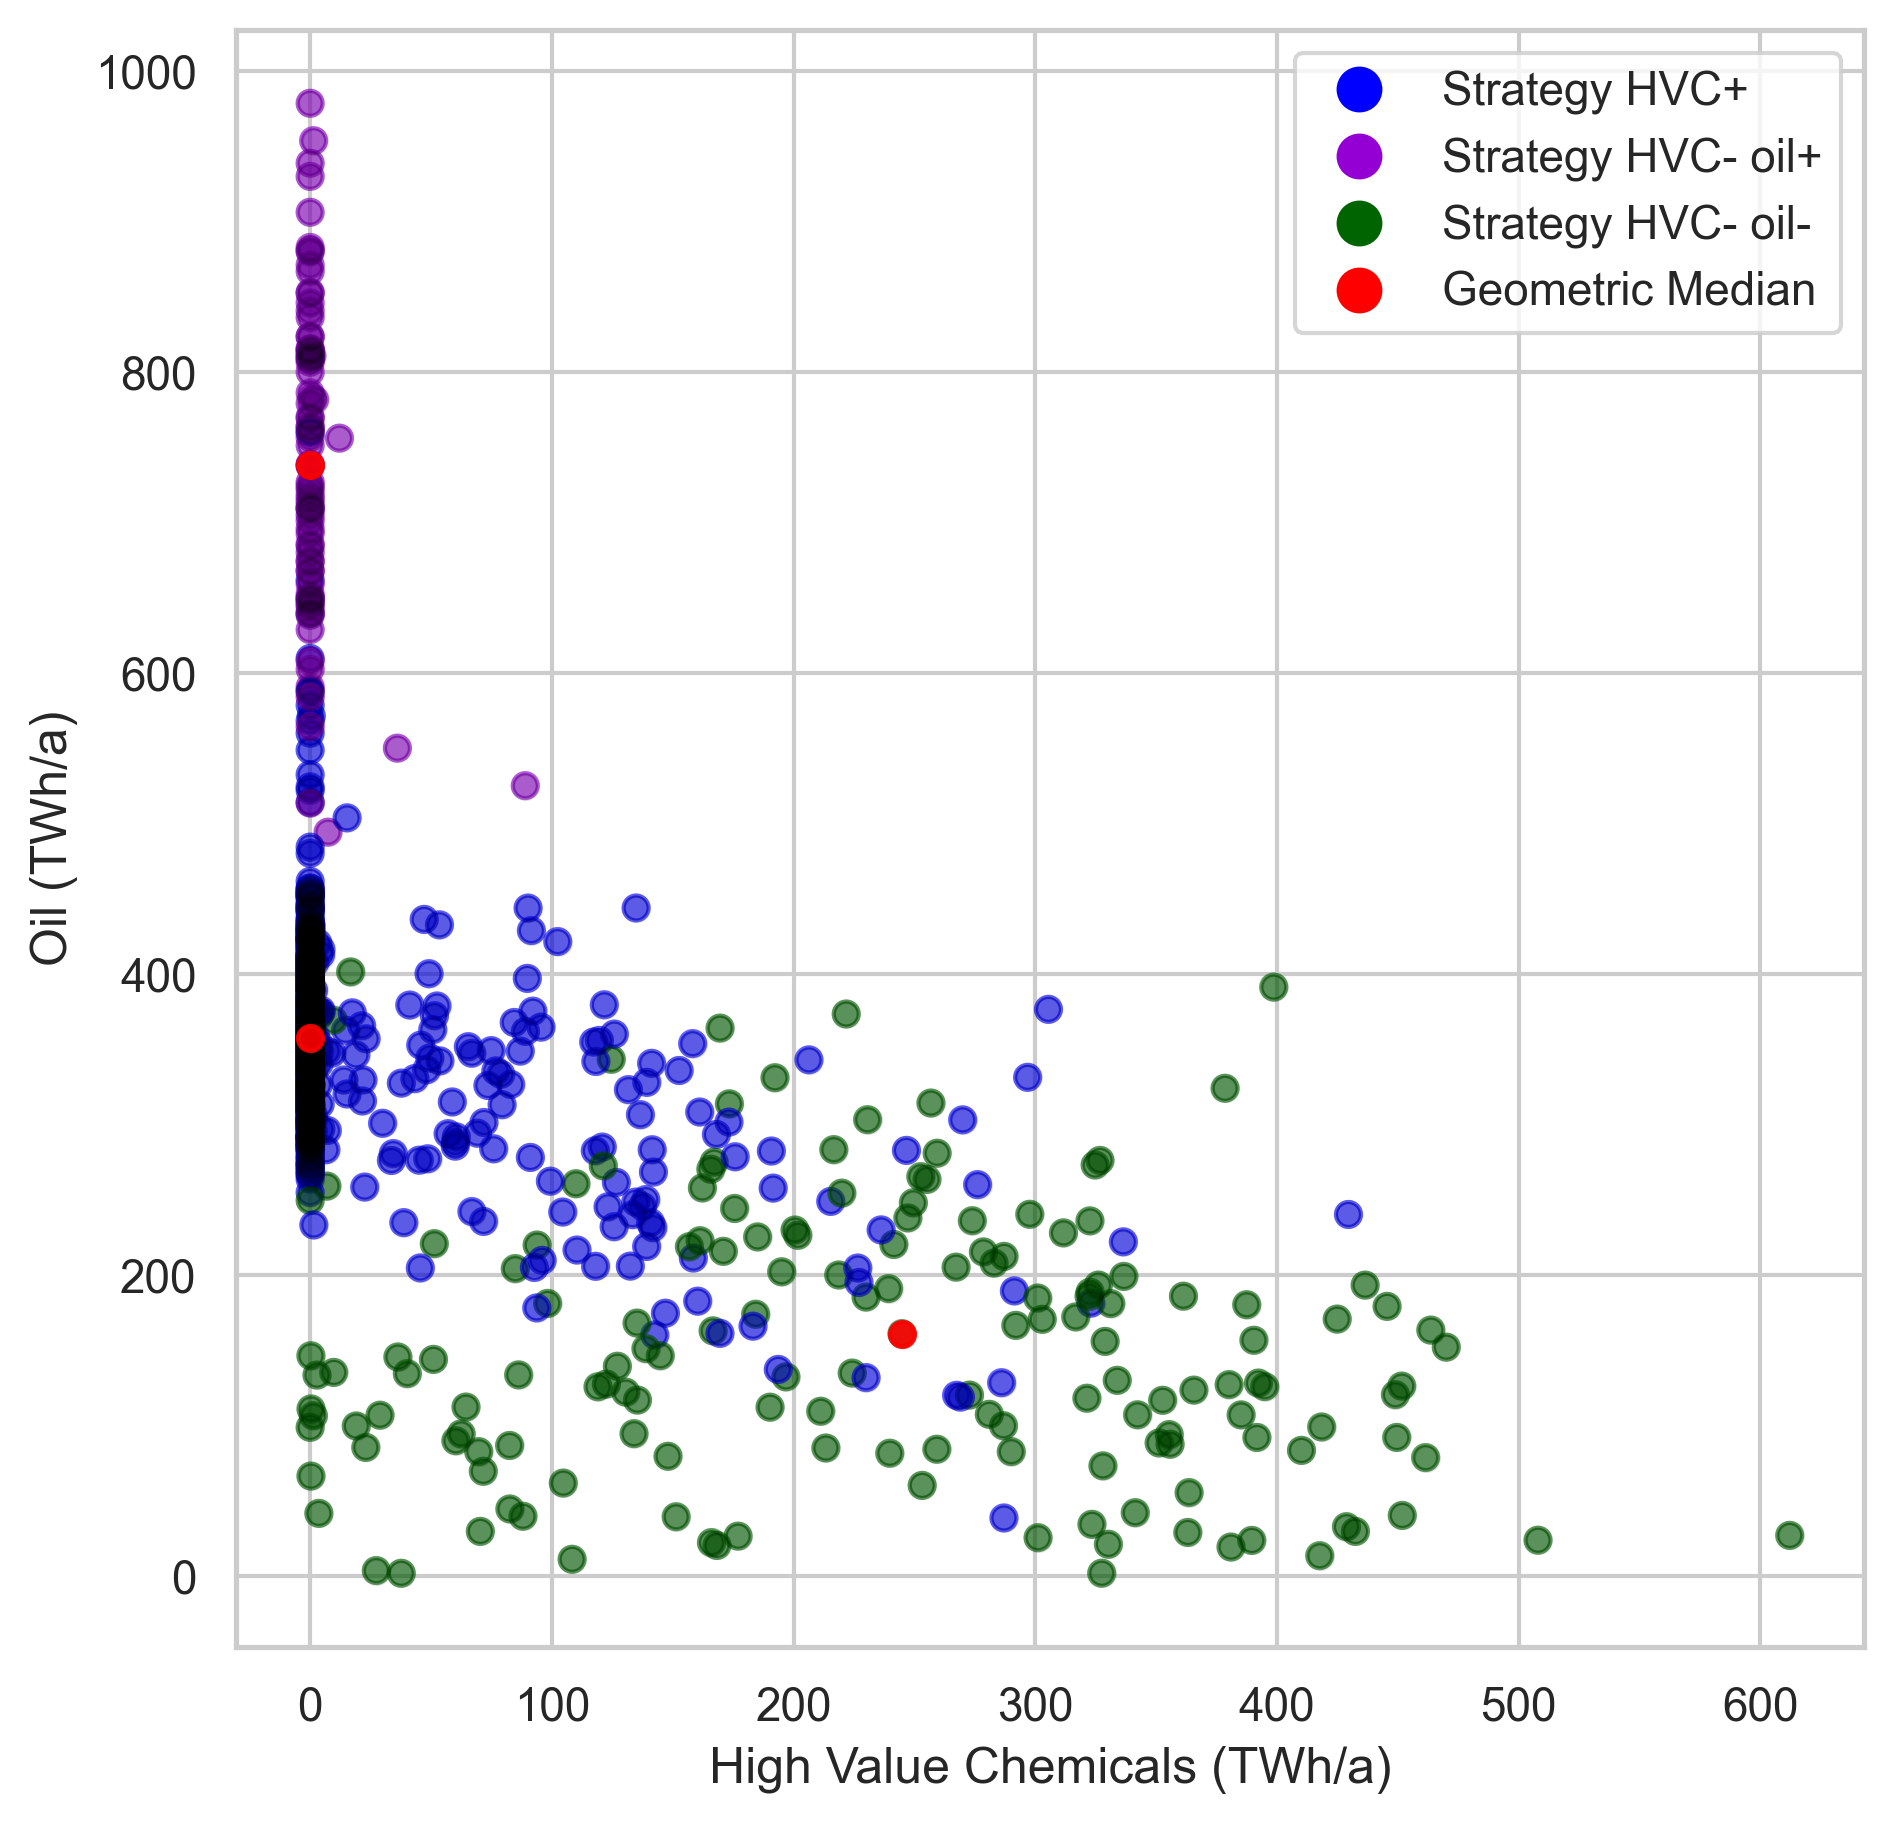

In [18]:
# Specify cut plane
X_AXIS = 'HTH'
Y_AXIS = 'crudeOil'

create_2D_side_view_plot(df_filtered_with_cluster, median_df, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, X_AXIS, Y_AXIS)

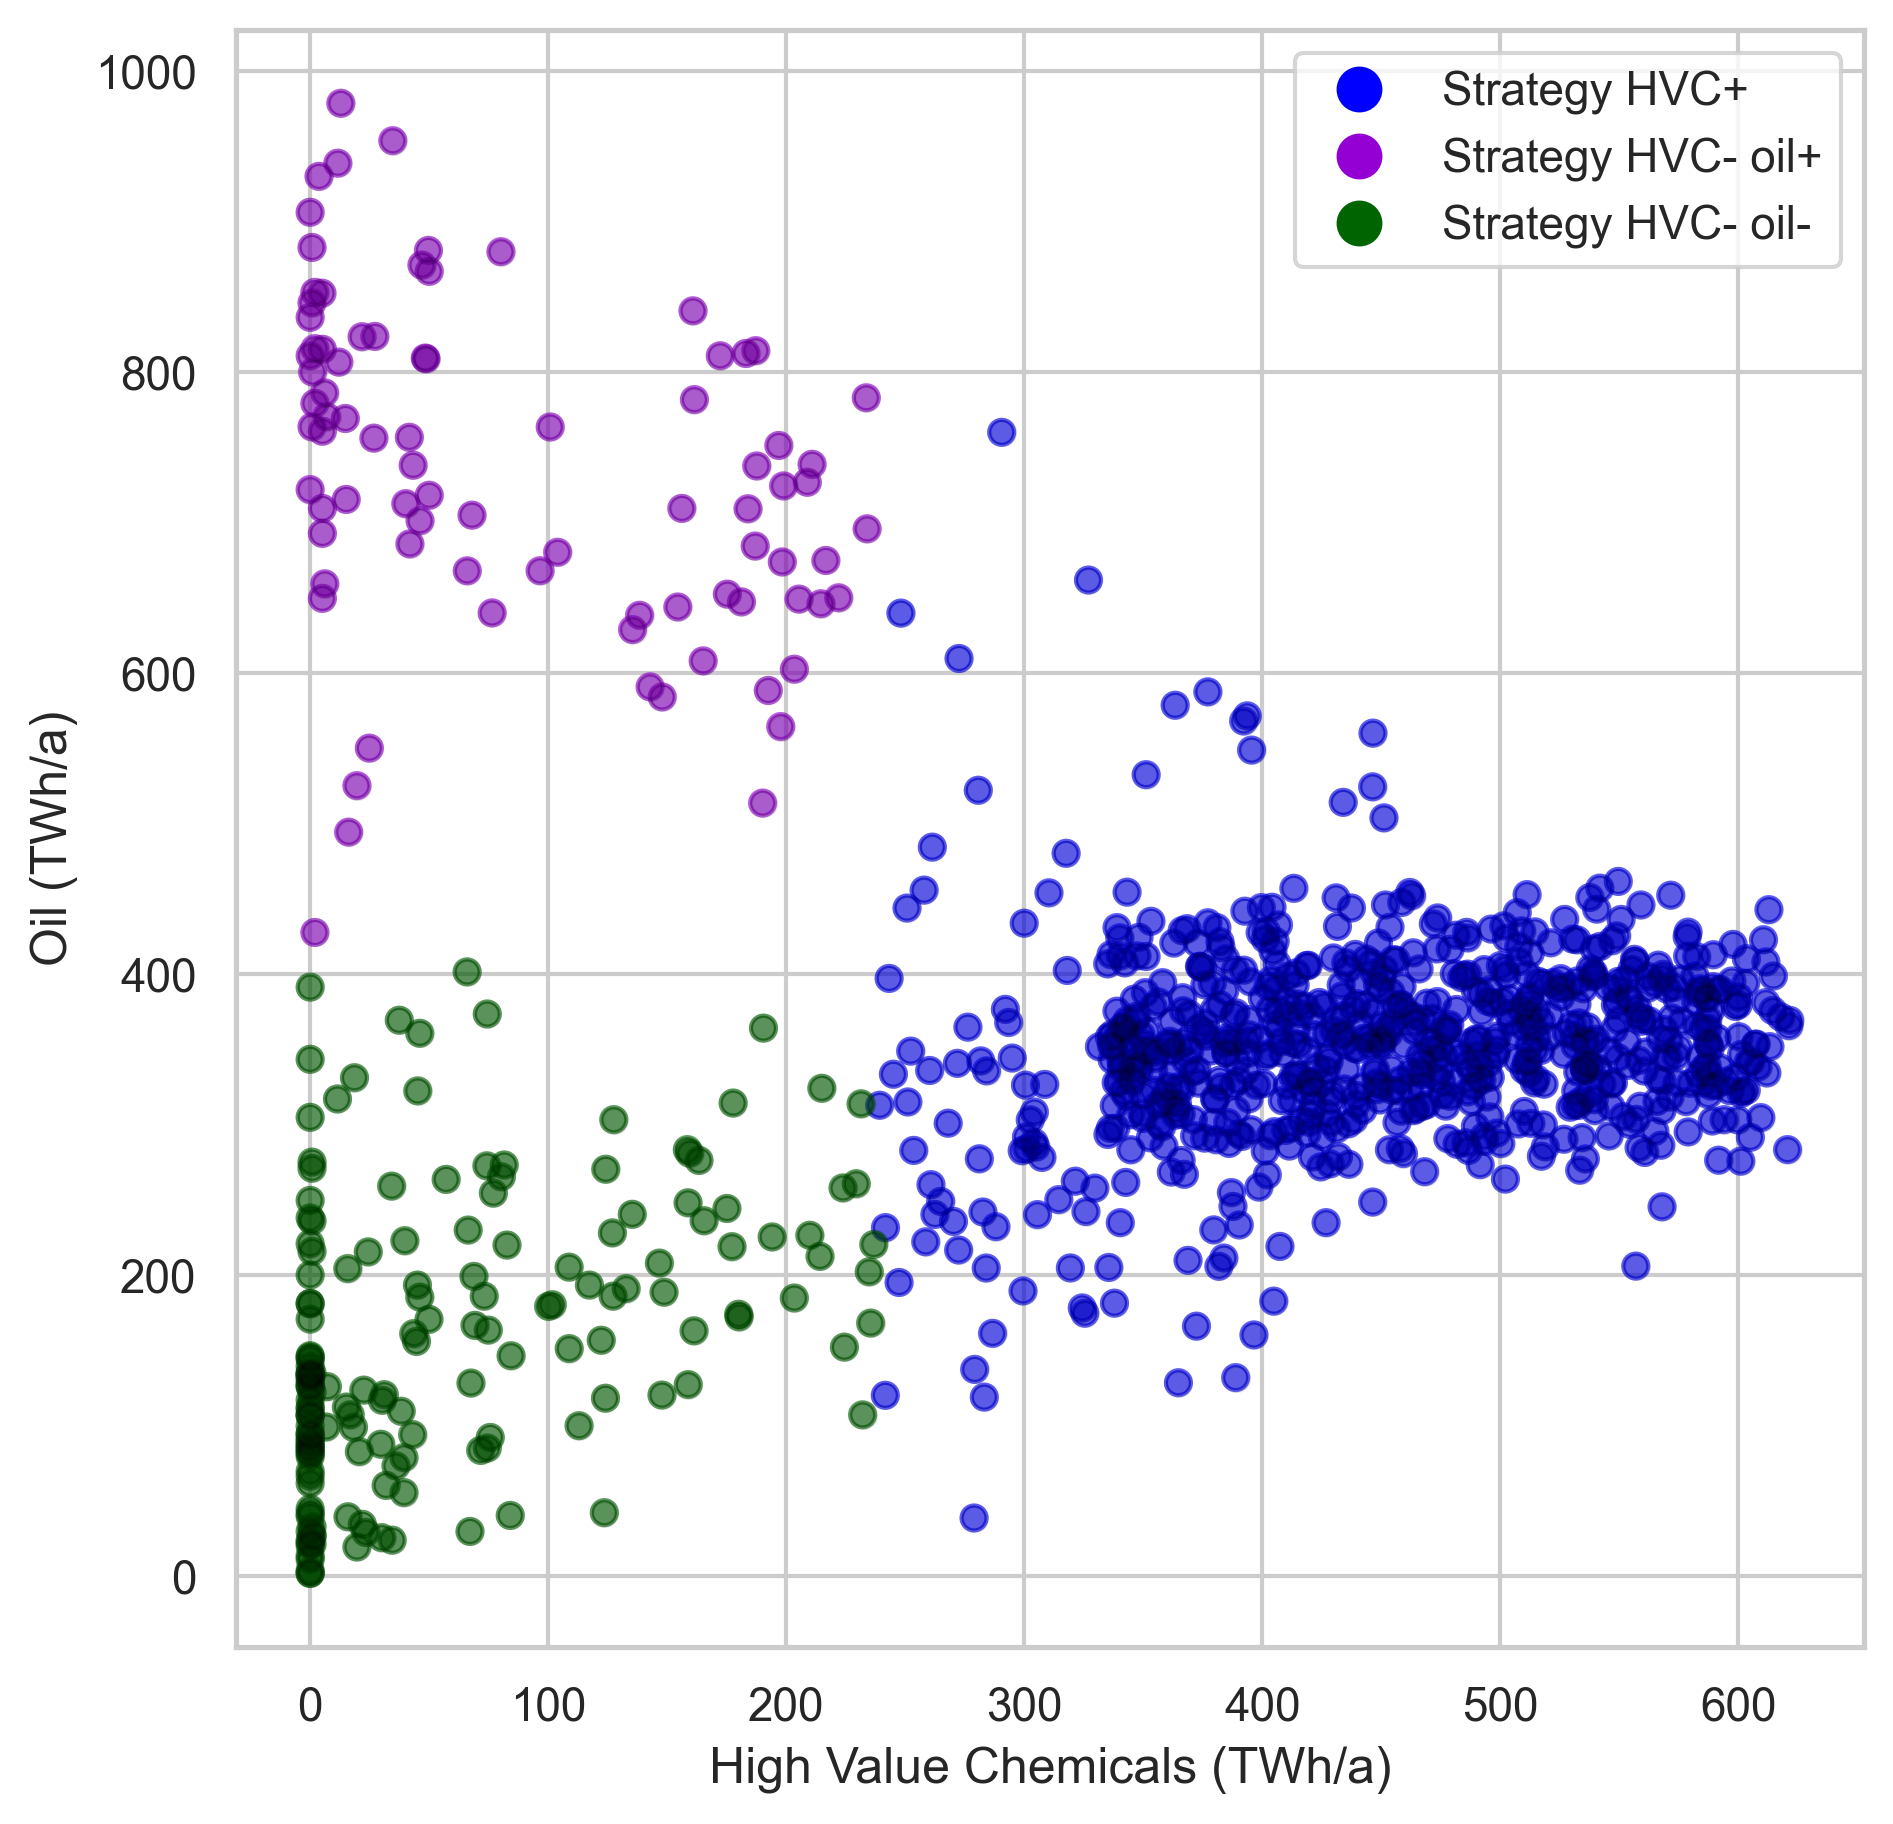

In [19]:
# Specify cut plane
X_AXIS = 'HVC'
Y_AXIS = 'crudeOil'

create_2D_side_view_plot(df_filtered_with_cluster, None, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, X_AXIS, Y_AXIS)

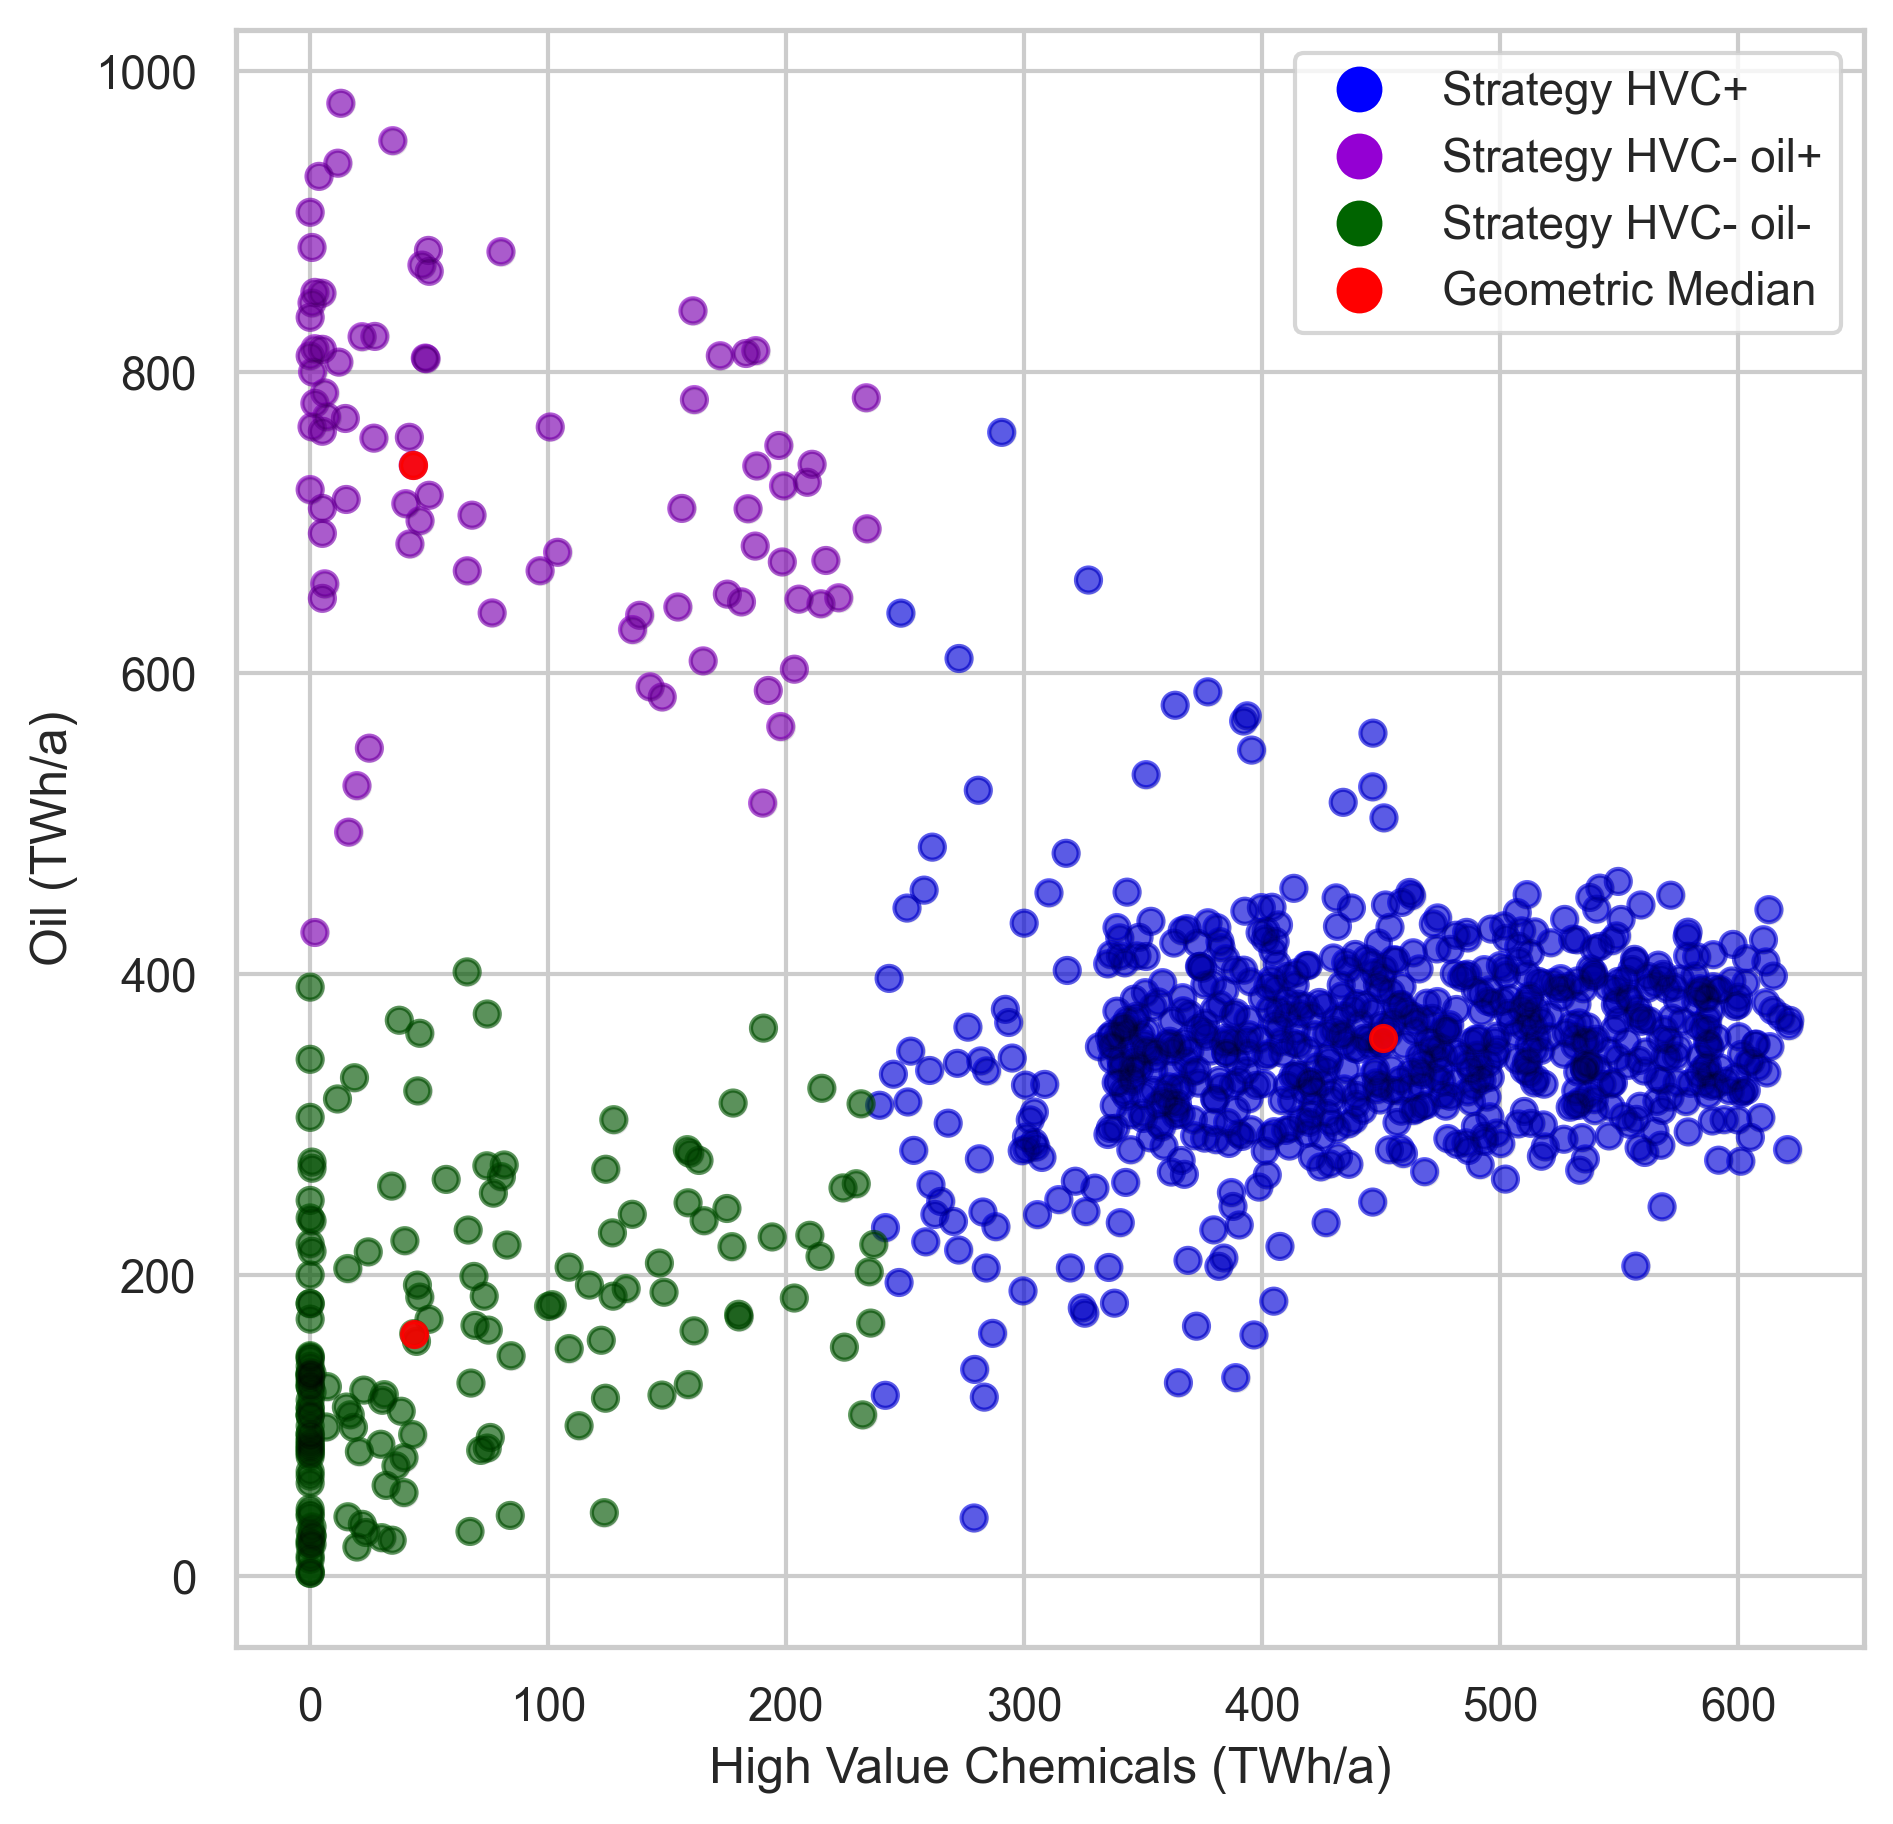

In [20]:
# Specify cut plane
X_AXIS = 'HVC'
Y_AXIS = 'crudeOil'

create_2D_side_view_plot(df_filtered_with_cluster, median_df, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, X_AXIS, Y_AXIS)

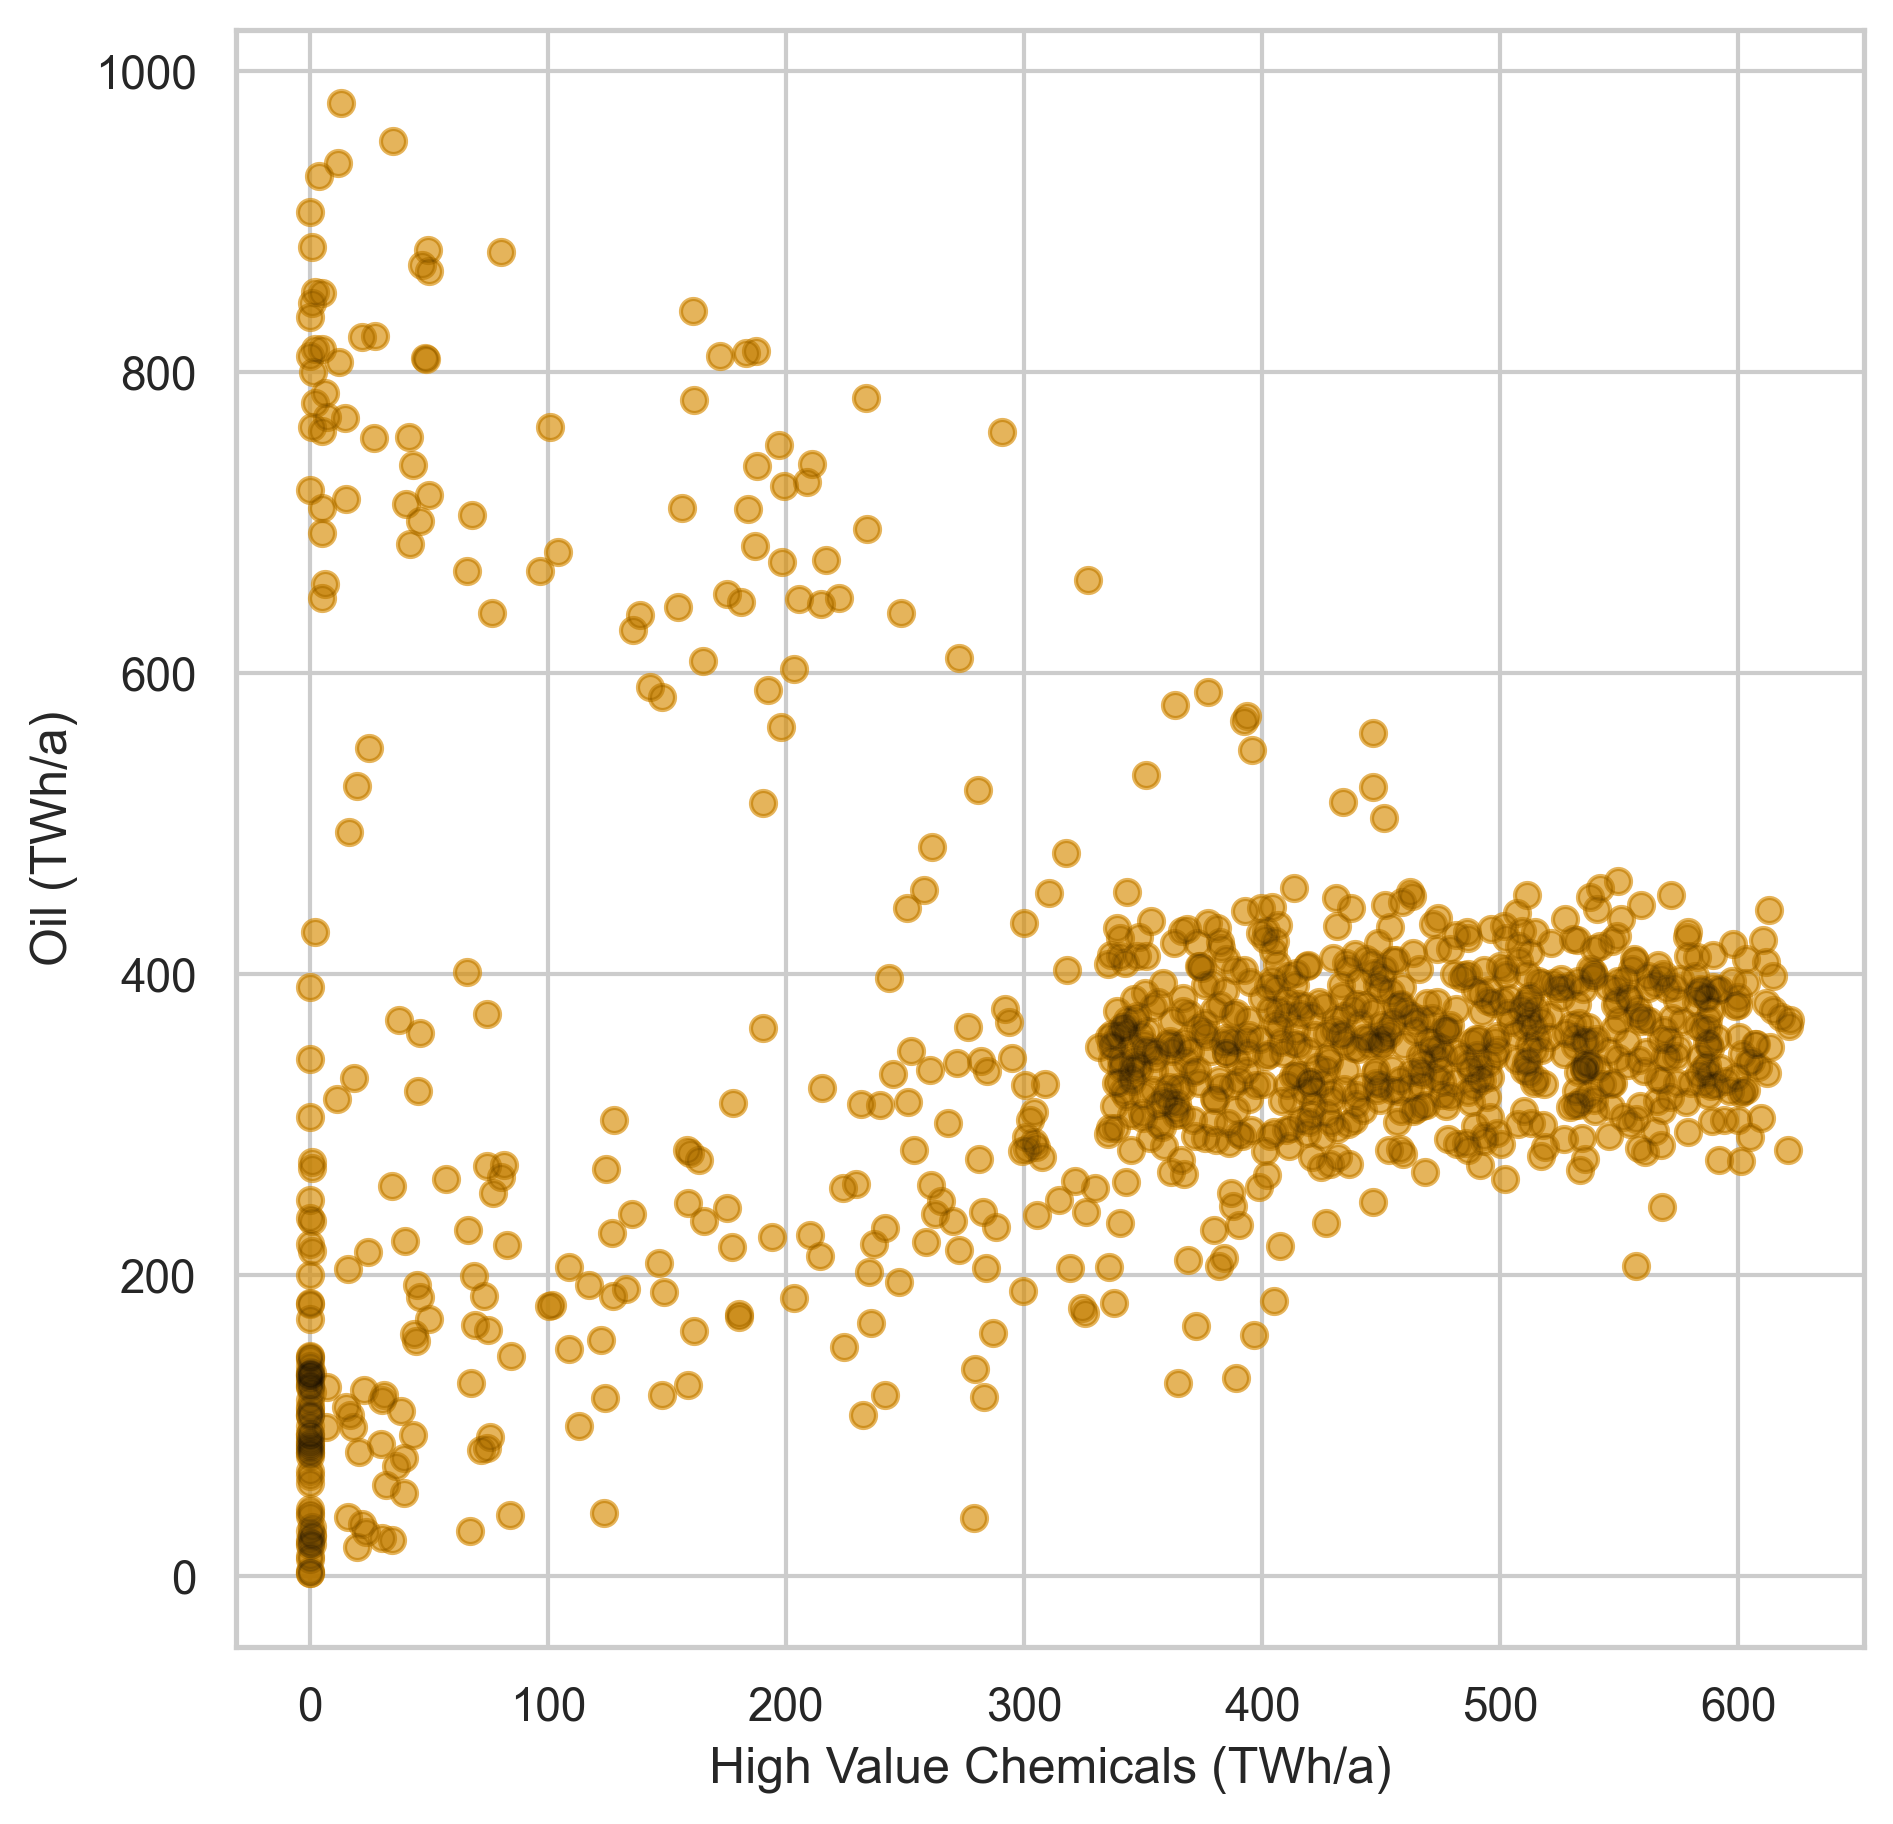

In [21]:
# Specify cut plane
X_AXIS = 'HVC'
Y_AXIS = 'crudeOil'


fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(111)

# Plot the side view (2D)
dots = ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], c='orange', alpha=0.6)
dots= ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], c='black', alpha=0.1)

ax.set_xlabel('High Value Chemicals (TWh/a)')
ax.set_ylabel('Oil (TWh/a)')

plt.show()


# Regret calculation
Before calculating the regret the model must be rerun with the additional constraint given from the decision tree. E.g. the cluster 0 has above 250 TWh/a of biomass use for crudeOil production. Therefore all scenarios belonging to cluster 1 must be rerun with the additional constraint of using at least 250 TWh/a of biomass for crudeOil production. The needed of this code in EuSysmod is a csv file containing the total cost for the scenarios which will be compared with the total cost of the same scenario without the additional constraint.

Make sure that the following files are in the data folder:
- total_cost.csv (from the uncostrained optimization)
- total_cost_cluster_0 (from all the scenarios not belonging to cluster 0 and the additional constraint)
- total_cost_cluster_1 (...)
- ...

Read the files and calculate the regret

In [22]:
# Read the CSV file with the unconstrained total cost
df_total_cost = pd.read_csv("data/merged_total_cost.csv", sep=",") 


# Create a dictionary to store the regret cost for each cluster
regret_cost = dict()

files = ["merged_total_cost_cluster_0.csv",
         "merged_total_cost_cluster_1.csv",
         "merged_total_cost_cluster_2.csv",
         "merged_total_cost_allLTH.csv",
         "merged_total_cost_noBiomass.csv",
         "merged_total_cost_onlyHvcAndOil.csv"]

names = ["cluster0",
            "cluster1",
            "cluster2",
            "allLTH",
            "noBiomass",
            "HVC_and_Oil"]

# for cluster in range(NUMBER_OF_CLUSTERS):   
for file, name in zip(files, names):
    # Read the CSV file for the cluster
    total_cost_cluster = pd.read_csv("data/" + file, sep=",") 
    print(name,":" ,len(total_cost_cluster))

    # Create a list in the dictionary for each cluster
    regret_cost[name] = [] 
    
    # iterate over each scenario and add the regret cost to the list in the dictionary
    for scenario in range(1, 1+len(df_total_cost)):
        if scenario in total_cost_cluster['iteration'].values:
             regret_cost[name].append( 
                total_cost_cluster[total_cost_cluster['iteration'] == scenario]["objectiveValue"].values[0] -
                df_total_cost[df_total_cost['iteration'] == scenario]["objectiveValue"].values[0]
            )
        else:
             regret_cost[name].append(0)



cluster0 : 834
cluster1 : 250
cluster2 : 916
allLTH : 1000
noBiomass : 1000
HVC_and_Oil : 1000


In [23]:
df_regret_cost = pd.DataFrame.from_dict(regret_cost)
df_regret_cost

,cluster0,cluster1,cluster2,allLTH,noBiomass,HVC_and_Oil
0,4442.891512,3463.809451,0.000000,43837.595054,20636.006682,-0.275864
1,7808.081498,0.000000,7709.239733,53441.486760,44326.025201,-0.600125
2,0.000000,3808.921629,6947.136497,14596.439319,317.141644,154.927052
3,0.000000,4177.984040,3489.991463,21694.642672,885.527975,2.868849
4,10161.411947,4540.780020,0.000000,58214.579236,44536.425591,0.071590
...,...,...,...,...,...,...
995,20504.697204,0.000000,10290.923008,87528.314310,61267.827225,-0.078993
996,6861.451722,1778.056415,0.000000,54491.792011,39655.937370,0.531460
997,10649.318182,155.619324,0.000000,64523.746919,47466.048516,-0.032006
998,6140.097739,11.468621,0.000000,44336.427517,25587.619401,0.268001


Create a plot with the number of scenarios having a lower regret than the x-value

In [24]:
from tabulate import tabulate
import csv

data = [
    ['Strategy', 'Max Regret', 'Average Regret', 'Optimal Scenarios'],
    ['regret cluster 1', int(df_regret_cost['cluster1'].max()), int(df_regret_cost['cluster1'].mean()), len(df_regret_cost[df_regret_cost['cluster1'] == 0])],
    ['regret cluster 2', int(df_regret_cost['cluster2'].max()), int(df_regret_cost['cluster2'].mean()), len(df_regret_cost[df_regret_cost['cluster2'] == 0])],
    ['regret cluster 0', int(df_regret_cost['cluster0'].max()), int(df_regret_cost['cluster0'].mean()), len(df_regret_cost[df_regret_cost['cluster0'] == 0])],
    ['regret allLTH', int(df_regret_cost['allLTH'].max()), int(df_regret_cost['allLTH'].mean()), len(df_regret_cost[df_regret_cost['allLTH'] < 5])],
    ['regret noBiomass', int(df_regret_cost['noBiomass'].max()), int(df_regret_cost['noBiomass'].mean()), len(df_regret_cost[df_regret_cost['noBiomass'] < 5])],
    ['regret HVC_and_Oil', int(df_regret_cost['HVC_and_Oil'].max()), int(df_regret_cost['HVC_and_Oil'].mean()), len(df_regret_cost[df_regret_cost['HVC_and_Oil'] < 5])]
]

headers = data[0]
table_data = data[1:]

table = tabulate(table_data, headers, tablefmt='grid')
print(table)


# Save table as CSV
with open('regret_table.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(data)




+--------------------+--------------+------------------+---------------------+
| Strategy           |   Max Regret |   Average Regret |   Optimal Scenarios |
+====================+==============+==================+=====================+
| regret cluster 1   |         7209 |              498 |                 750 |
+--------------------+--------------+------------------+---------------------+
| regret cluster 2   |        19710 |             4898 |                  84 |
+--------------------+--------------+------------------+---------------------+
| regret cluster 0   |        30881 |             6454 |                 166 |
+--------------------+--------------+------------------+---------------------+
| regret allLTH      |       116961 |            49077 |                   0 |
+--------------------+--------------+------------------+---------------------+
| regret noBiomass   |        95127 |            32844 |                   0 |
+--------------------+--------------+---------------

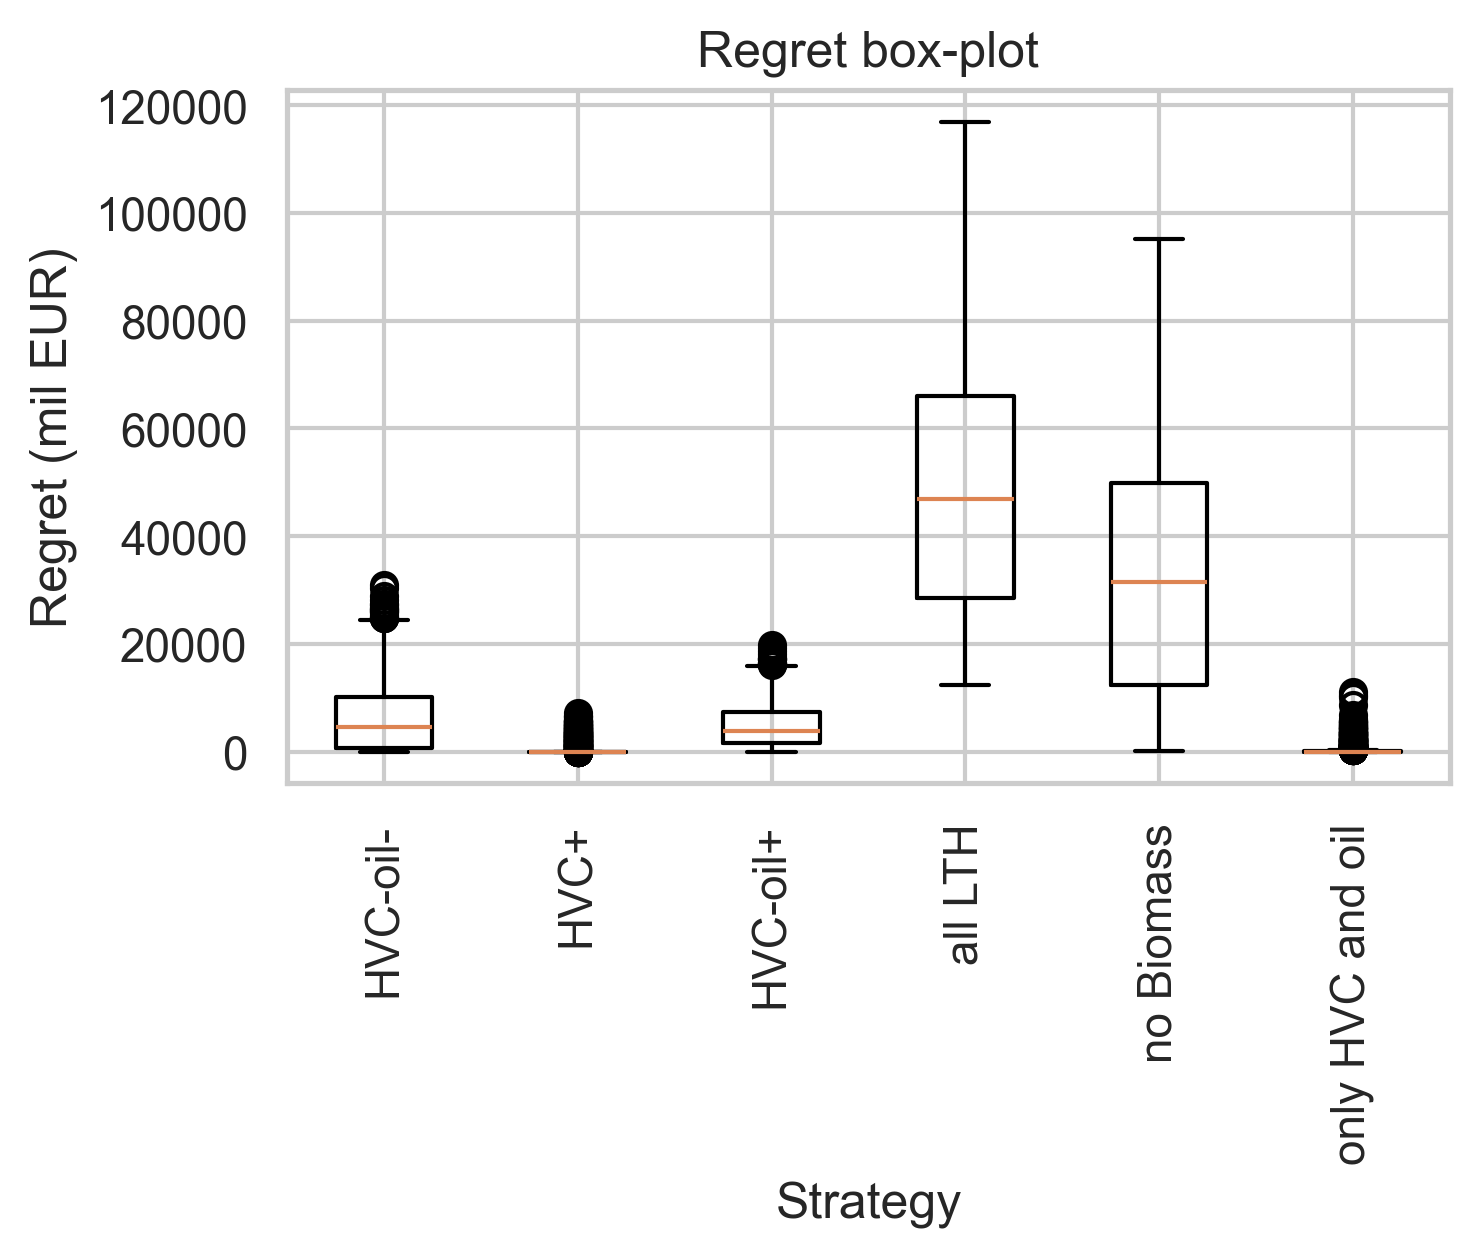

In [25]:
# Create a boxplot
plt.figure(figsize=(5, 3), dpi=300)
plt.boxplot(df_regret_cost.values)
# The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers.

# Set the x-axis tick labels
plt.xticks(range(1, len(df_regret_cost.columns) + 1), ['HVC-oil-', 'HVC+', 'HVC-oil+', 'all LTH', 'no Biomass', 'only HVC and oil'], rotation=90)
                                                       

# Set the y-axis label
plt.ylabel('Regret (mil EUR)')
plt.xlabel('Strategy')

# Set the title
plt.title('Regret box-plot')

# Show the plot
plt.show()

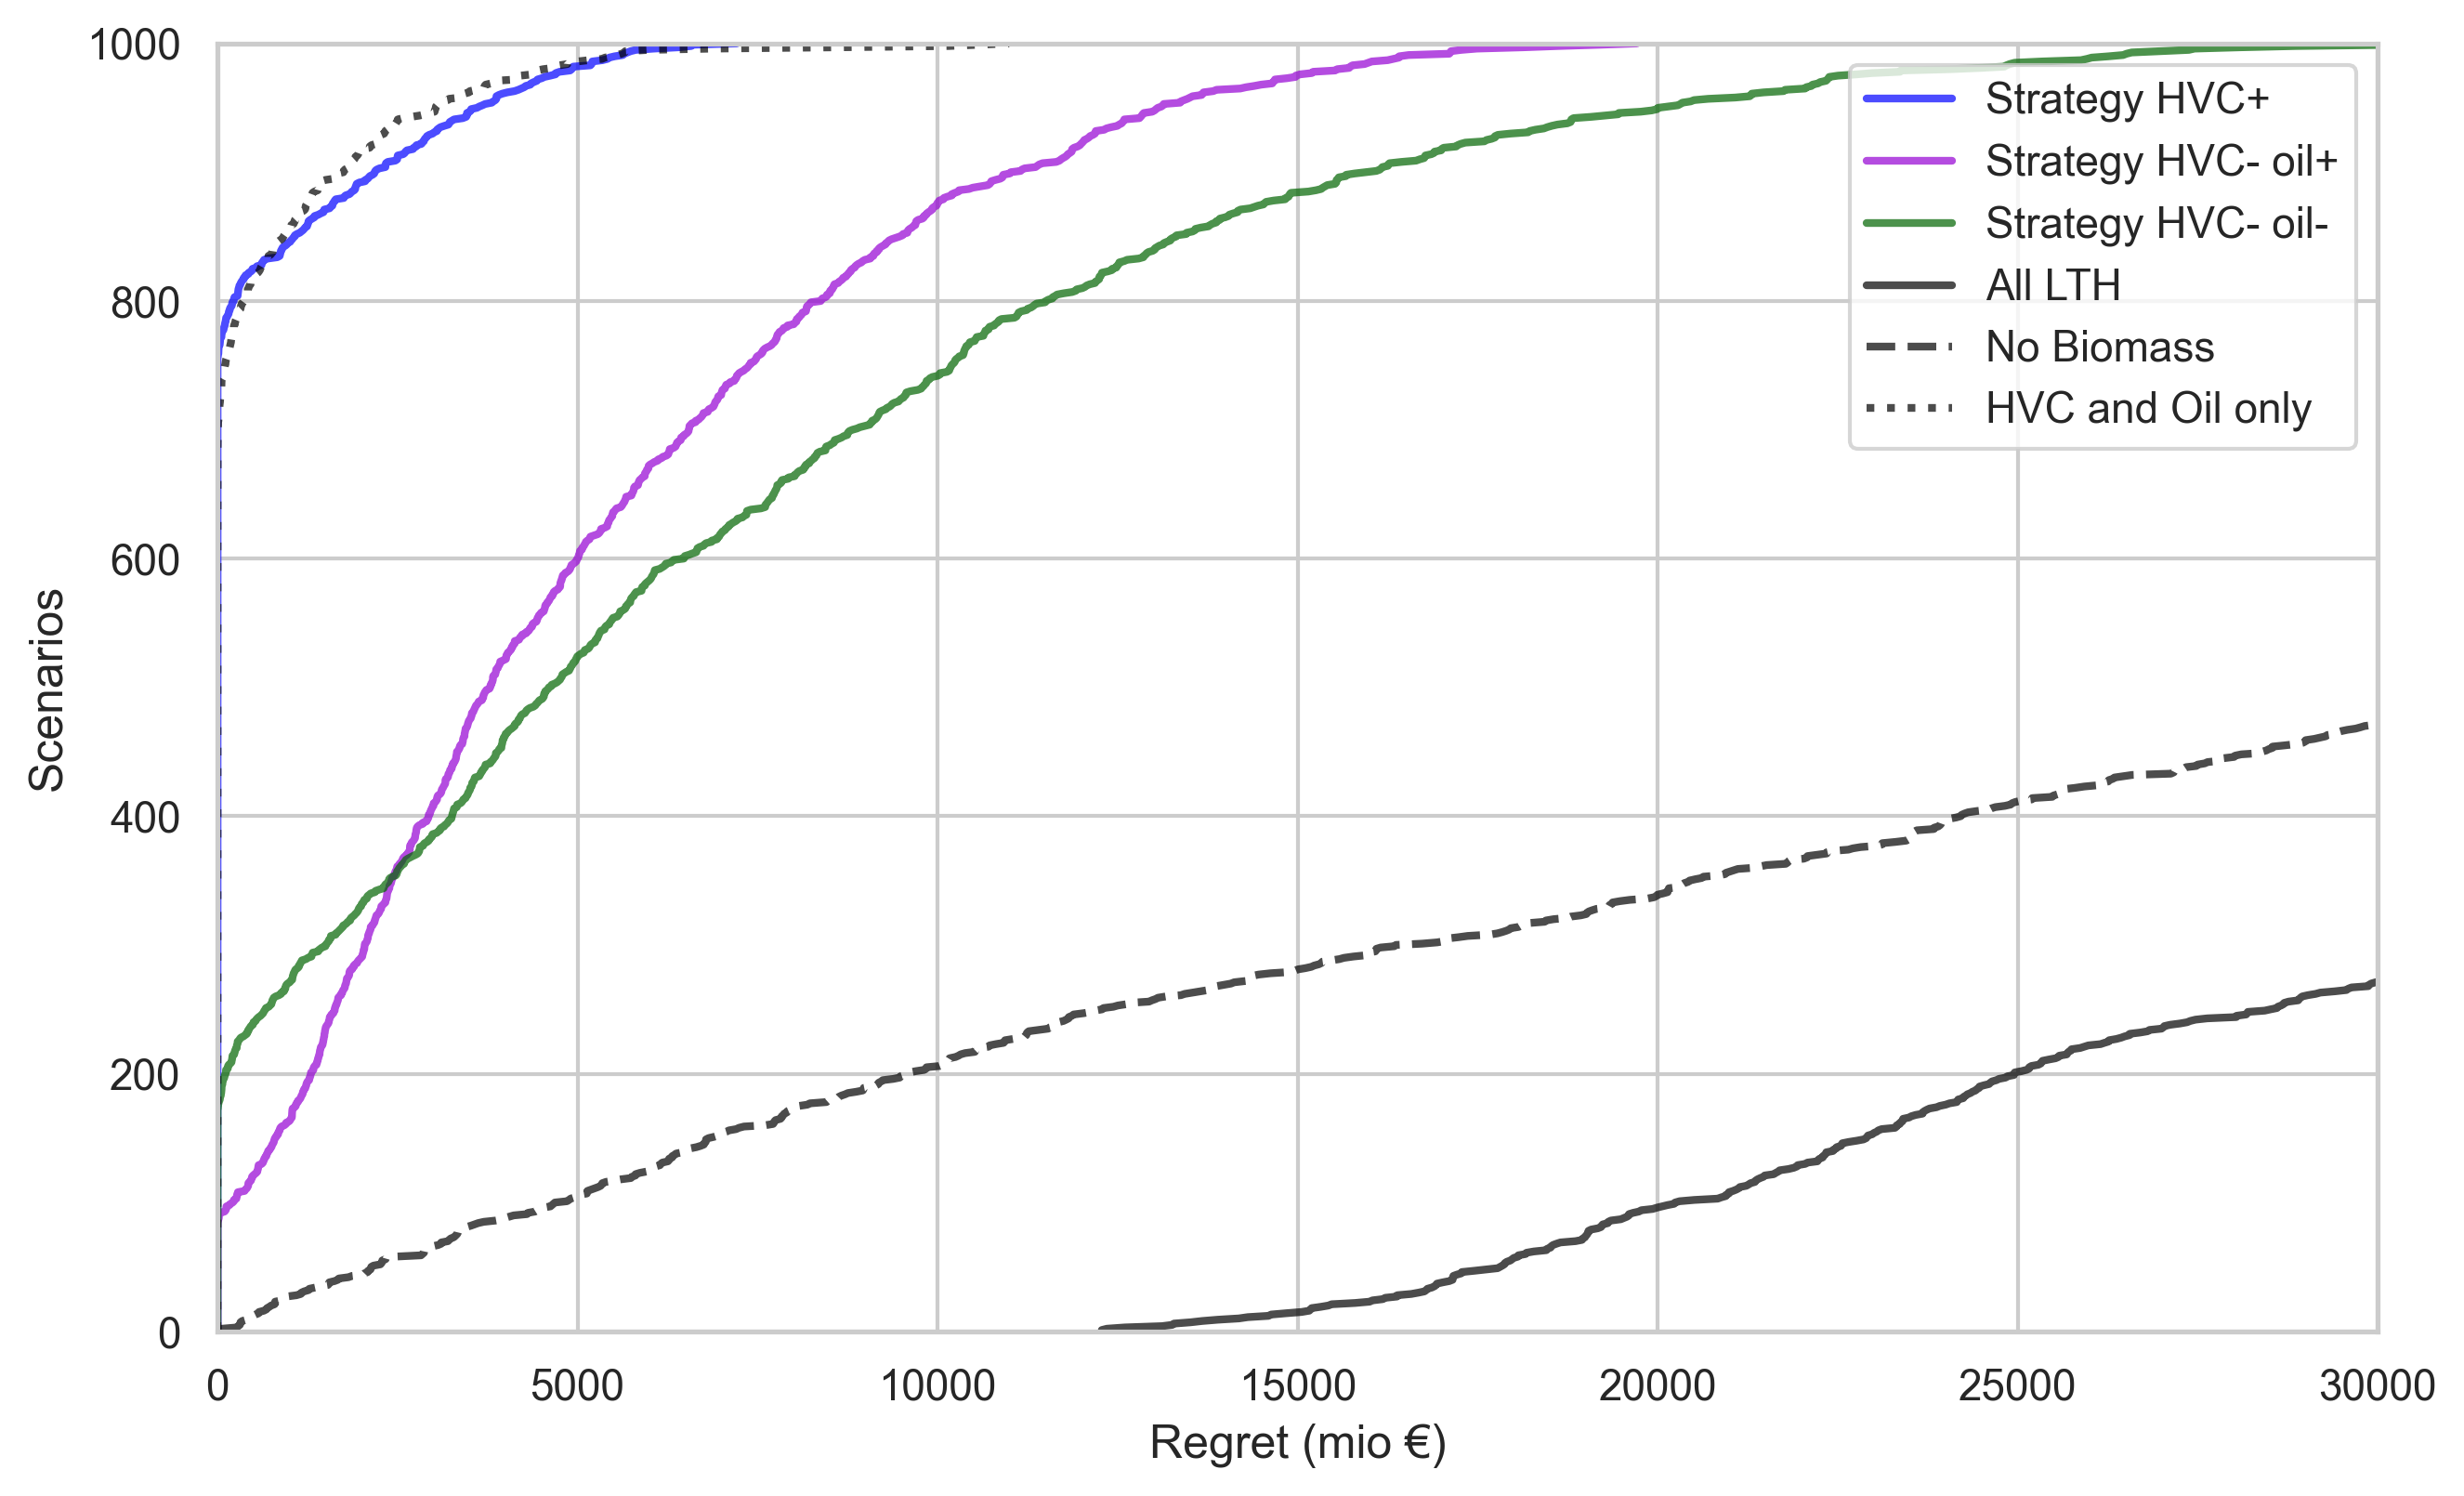

In [26]:

scnarios = np.arange(1, len( regret_cost[f"cluster{cluster}"]) + 1) # Create an array for the y-axis values

# Plot the data
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(np.sort(regret_cost["cluster1"]), scnarios, color=COLOR_MAP[1], alpha=0.7, linestyle='-', linewidth=2, label=STRATEGY_NAMES[1])
plt.plot(np.sort(regret_cost["cluster2"]), scnarios, color=COLOR_MAP[2], alpha=0.7, linestyle='-', linewidth=2, label=STRATEGY_NAMES[2])
plt.plot(np.sort(regret_cost["cluster0"]), scnarios, color=COLOR_MAP[0], alpha=0.7, linestyle='-', linewidth=2, label=STRATEGY_NAMES[0])
plt.plot(np.sort(regret_cost["allLTH"]), scnarios, color='black', alpha=0.7, linestyle='-', linewidth=2, label='All LTH')
plt.plot(np.sort(regret_cost["noBiomass"]), scnarios, color='black', alpha=0.7, linestyle='--', linewidth=2, label='No Biomass')
plt.plot(np.sort(regret_cost["HVC_and_Oil"]), scnarios, color='black', alpha=0.7, linestyle=':', linewidth=2, label='HVC and Oil only')


# Set the y-axis limits
plt.ylim(0, len(df_total_cost))
plt.xlim(0, 30000)
# plt.xlim(0, max(max(regret_cost.values())))

# Set the title and labels
# plt.title('Regret calculation')
plt.xlabel('Regret (mio €)')
plt.ylabel('Scenarios')

# Add a legend
plt.legend(loc='upper right')


plt.savefig("results/regret.svg",  format="svg")
plt.savefig("results/regret.pdf")


# Show the plot
plt.show()


In [27]:
# Check for negative regrets
for cluster in {0, 1, 2}:
    for index, regret in enumerate(regret_cost[f"cluster{cluster}"]):
        if regret <0: print(f"Scenario {index+1}: {regret:.2f} mio €") 

Scenario 374: -0.13 mio €
Scenario 600: -0.12 mio €
Scenario 283: -0.28 mio €
Scenario 335: -0.08 mio €


# Further usage analysis

For further analysis the usage of the biomass carriers as well as the usage of syngas and oil can be analyzed to gain insights in which sector the oil/syngas is used.

To do so safe the usage files generated in every iteration from during the EuSysMod execution in the folder "usage".

In [28]:
df = pd.read_csv("data/usage/biomassUsage_iteration_1.csv", sep=",") 

for i in range(2,301, 1):
    file_location = f"data/usage/biomassUsage_iteration_{i}.csv"
    df  += pd.read_csv(file_location, sep=",") 

df.carrier = pd.read_csv("data/usage/biomassUsage_iteration_1.csv", sep=",").carrier

# Apply the abs() function only to the numeric columns
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].abs()

# Identify the highest value in the numeric columns of the DataFrame
max_value = df[numeric_cols].max().max()

# Compute 5% of the highest value
threshold = 0.05 * max_value

# Remove numeric columns where the maximum value is less than the threshold
cols_to_keep = df.select_dtypes(exclude='number').columns.tolist()
cols_to_keep += [col for col in numeric_cols if df[col].max() >= threshold]

# Filter the DataFrame to keep only the relevant columns
df = df[cols_to_keep]

# Print the table
print(tabulate(df, headers= 'keys', tablefmt="grid"))

+----+------------+----------------+----------------+----------------+----------------+
|    | carrier    |   pyrolysisOil |   biomassToHvc |   liquefaction |   gasification |
+====+============+================+================+================+================+
|  0 | wood       |      0.0357171 |         144365 |       0        |       0.376707 |
+----+------------+----------------+----------------+----------------+----------------+
|  1 | greenWaste |  49629         |              0 |       0.480641 |       0.477768 |
+----+------------+----------------+----------------+----------------+----------------+
|  2 | manure     |      0         |              0 |   23349.1      |   30534.4      |
+----+------------+----------------+----------------+----------------+----------------+
|  3 | sludge     |      0         |              0 |    2862.11     |       0.560905 |
+----+------------+----------------+----------------+----------------+----------------+
|  4 | digestate  |      0      

In [29]:

df = pd.read_csv("data/usage/oilSyngas_usage_iteration_1.csv", sep=",") # Read the CSV file

for i in range(2,301, 1):
    file_location = f"data/usage/oilSyngas_usage_iteration_{i}.csv"
    df  += pd.read_csv(file_location, sep=",") # Read the CSV file



df.carrier = pd.read_csv("data/usage/oilSyngas_usage_iteration_1.csv", sep=",").carrier

# Apply the abs() function only to the numeric columns
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].abs()

# Identify the highest value in the numeric columns of the DataFrame
max_value = df[numeric_cols].max().max()

# Compute 5% of the highest value
threshold = 0.05 * max_value

# Remove numeric columns where the maximum value is less than the threshold
cols_to_keep = df.select_dtypes(exclude='number').columns.tolist()
cols_to_keep += [col for col in numeric_cols if df[col].max() >= threshold]

# Filter the DataFrame to keep only the relevant columns
df = df[cols_to_keep]

# Print the table
print(tabulate(df, headers= 'keys', tablefmt="grid"))

+----+------------+------------+------------------+---------------+------------+----------------+---------------+-----------------------------+-------------------+
|    | carrier    |   refinery |   avaAndNaviTech |   Methanation |   gasToHvc |   h2ToCrudeOil |   h2ToMethane |   haberBoschH2AmmoniaProLow |   h2BoilerProHigh |
+====+============+============+==================+===============+============+================+===============+=============================+===================+
|  0 | crudeOil   |     254805 |                0 |           0   |          0 |              0 |             0 |                         0   |                 0 |
+----+------------+------------+------------------+---------------+------------+----------------+---------------+-----------------------------+-------------------+
|  1 | refinedOil |          0 |           242057 |           0   |          0 |              0 |             0 |                         0   |                 0 |
+----+----------

# 2D Image of biomass usage after applying the strategies

In [30]:
# df_input = pd.read_csv("data/outputsOfInterest.csv", sep=",") # Read the CSV file
df_input = pd.read_csv(r"C:\Users\olive\Desktop\Projects\EuSysMod\results\V1.2\initial\merged_outputsOfInterest.csv", sep=",") # Read the CSV file
df_input= df_input.abs() # Take the absolute value of all columns



## combine categories
df_input['LTH'] = df_input['LTH'] + df_input['DH'] + df_input['SpaceHeating'] # Combine 'LTH', 'DH', and 'SpaceHeating' columns
df_input = df_input.drop(columns=['DH', 'SpaceHeating']) # Drop the original 'DH' and 'SpaceHeating' columns
df_input['HTH'] = df_input['MTH'] + df_input['HTH'] # Combine 'MTH' and 'HTH' 
df_input = df_input.drop(columns=['MTH']) # Drop the original 'DH' and 'SpaceHeating' columns

In [31]:
# Read and process df_output_of_interest_with_constraint
df_output_of_interest_with_constraint = pd.read_csv(r"C:\Users\olive\Desktop\Projects\EuSysMod\results\V1.2\regret_cluster_1\merged_outputsOfInterest.csv", sep=",")
df_output_of_interest_with_constraint = df_output_of_interest_with_constraint.abs()  # Take the absolute value of all columns

# Combine categories
df_output_of_interest_with_constraint['LTH'] = df_output_of_interest_with_constraint['LTH'] + df_output_of_interest_with_constraint['DH'] + df_output_of_interest_with_constraint['SpaceHeating']
df_output_of_interest_with_constraint = df_output_of_interest_with_constraint.drop(columns=['DH', 'SpaceHeating'])
df_output_of_interest_with_constraint['HTH'] = df_output_of_interest_with_constraint['MTH'] + df_output_of_interest_with_constraint['HTH']
df_output_of_interest_with_constraint = df_output_of_interest_with_constraint.drop(columns=['MTH'])

# Find the missing iterations
missing_iterations = set(range(1, 1001)) - set(df_output_of_interest_with_constraint['iteration'])

# Create a DataFrame with the missing iterations from df_input
missing_df = df_input[df_input['iteration'].isin(missing_iterations)].copy()

# Concatenate the missing DataFrame with the original DataFrame
df_output_of_interest_with_constraint = pd.concat([df_output_of_interest_with_constraint, missing_df], ignore_index=True)

# Sort the DataFrame by iteration
df_output_of_interest_with_constraint = df_output_of_interest_with_constraint.sort_values('iteration')

# Reset the index
df_output_of_interest_with_constraint = df_output_of_interest_with_constraint.reset_index(drop=True)

# Fill the missing values with zeros
# df_output_of_interest_with_constraint = df_output_of_interest_with_constraint.fillna(0)



df_output_of_interest_with_constraint_and_cluster = df_filtered_with_cluster.copy()

df_output_of_interest_with_constraint_and_cluster[["crudeOil", "HVC", "CHP", "LTH", "HTH", "rawBiogas", "syngas", "coal"]] = df_output_of_interest_with_constraint[["crudeOil", "HVC", "CHP", "LTH", "HTH", "rawBiogas", "syngas", "coal"]]



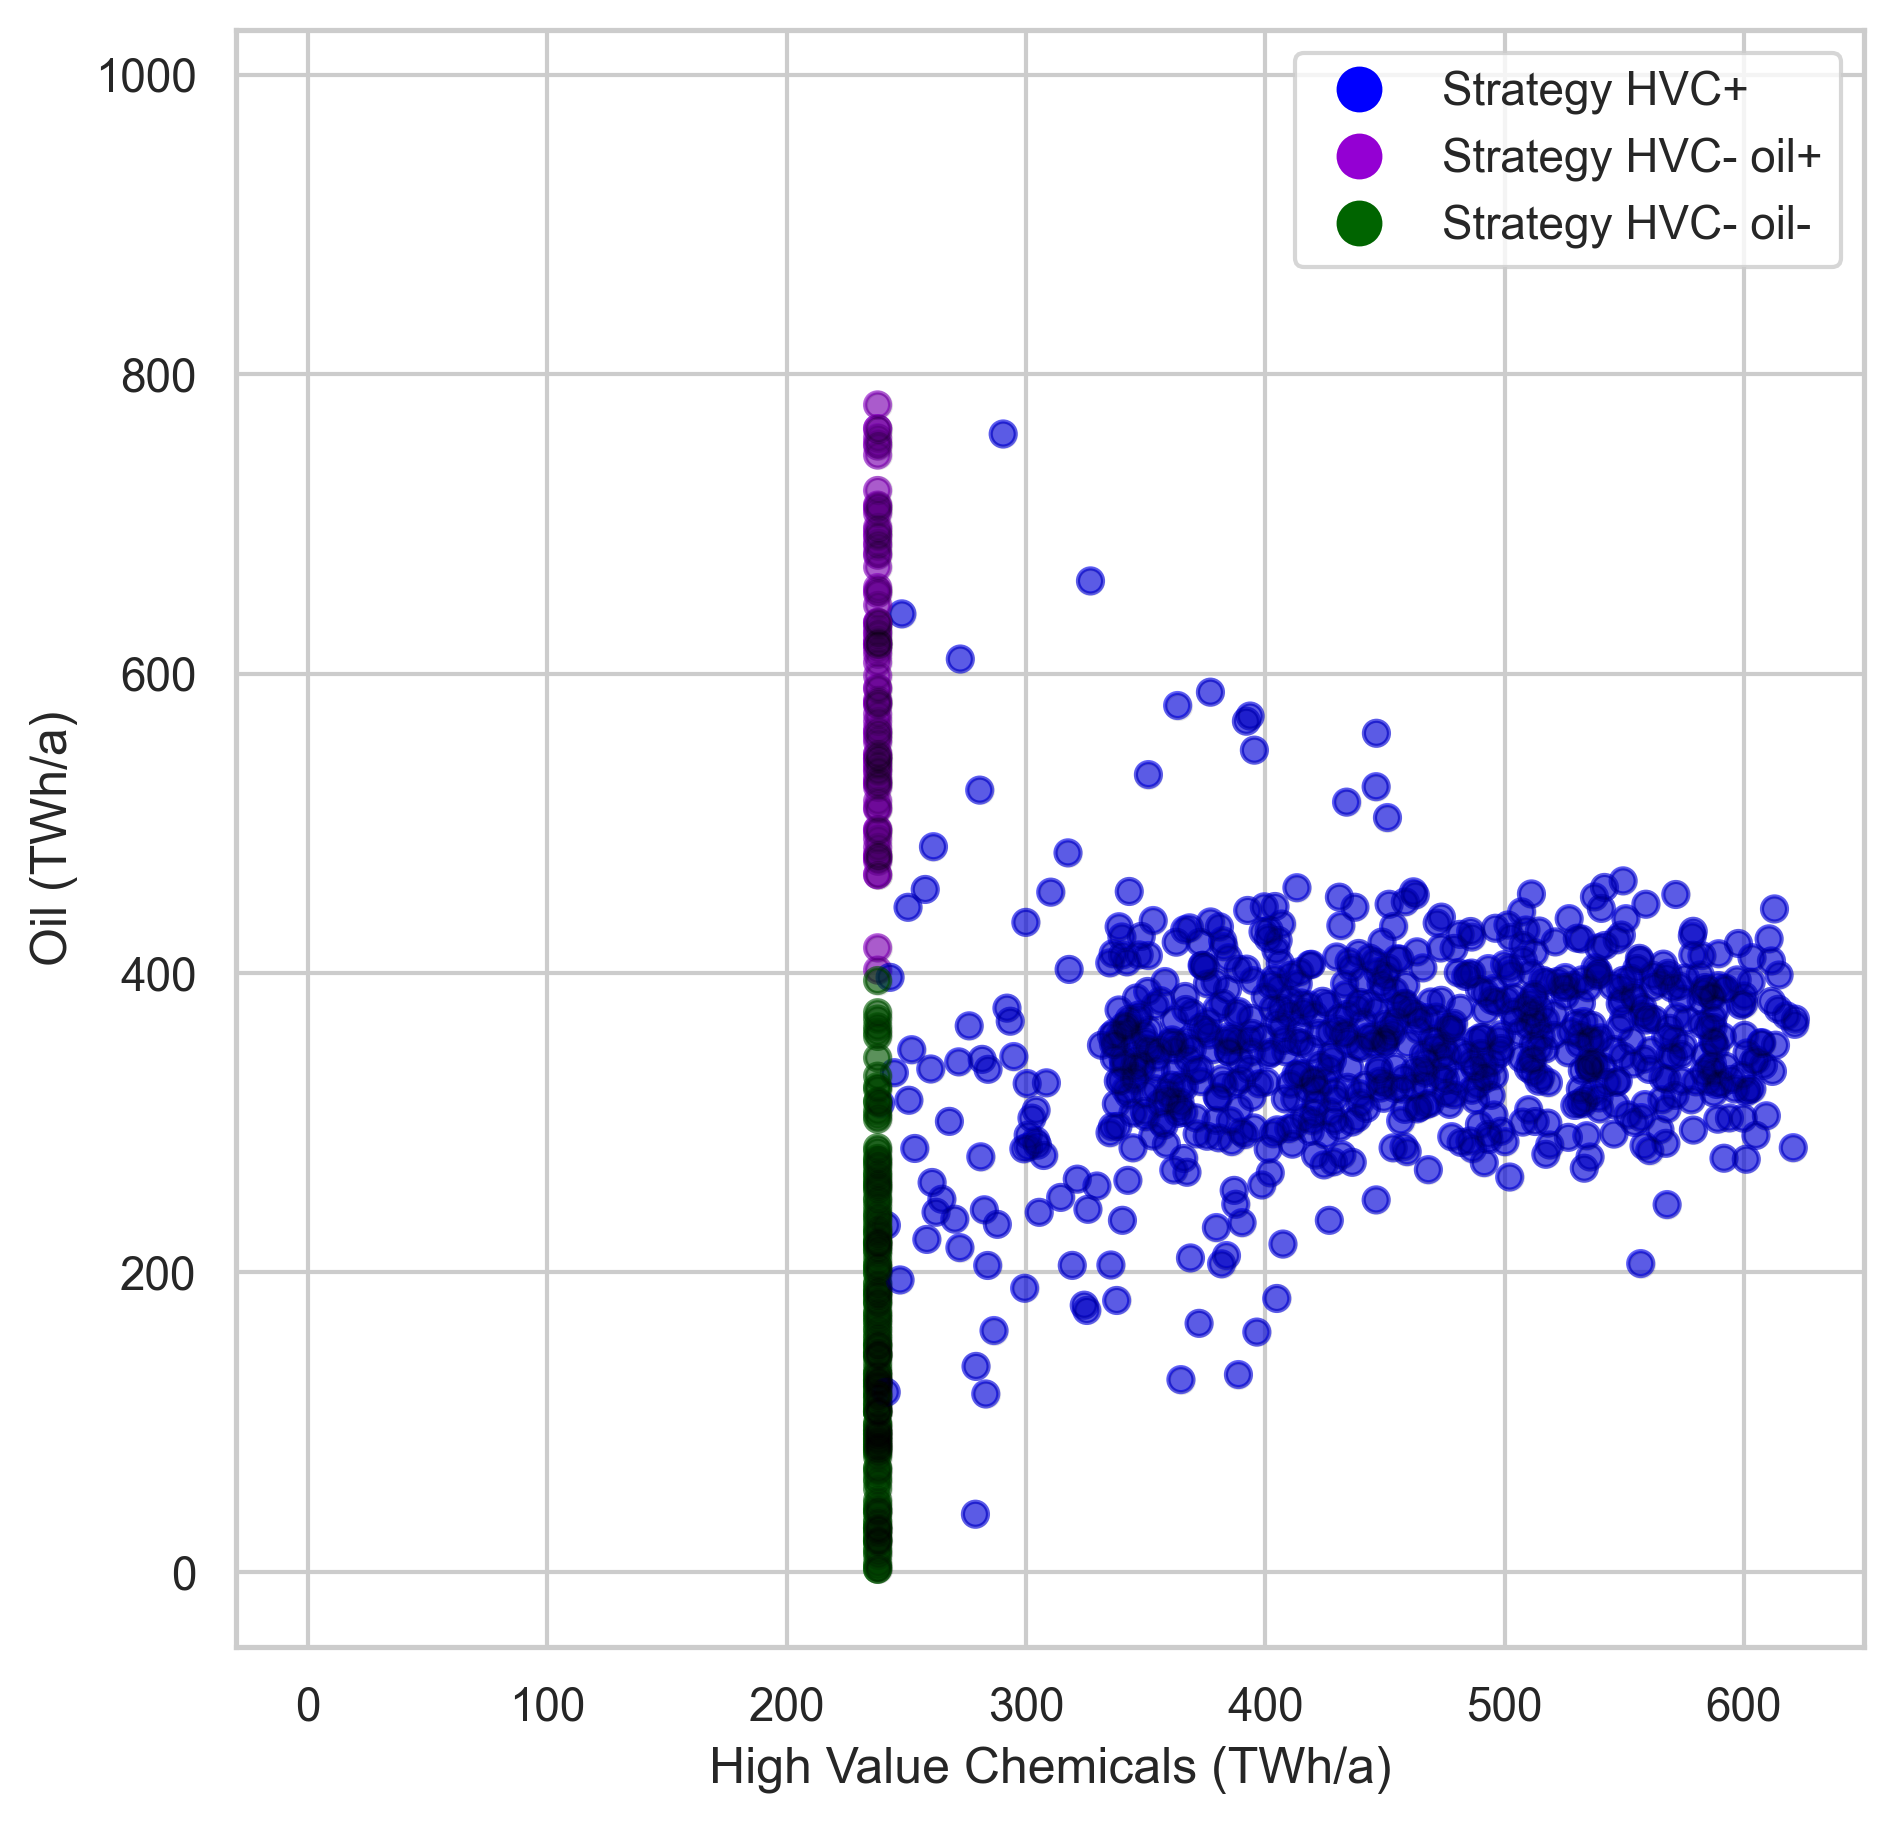

In [32]:
create_2D_side_view_plot(df_output_of_interest_with_constraint_and_cluster , None, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, "HVC", "crudeOil", limits=True)

# Create scatter plots to show the usage of biomass with and without constraints

Prepare Data

In [33]:
df_output_of_interest_optimal = pd.read_csv(r"C:\Users\olive\Desktop\Projects\EuSysMod\results\V1.2\initial\merged_outputsOfInterest.csv", sep=",") # Read the CSV file

## combine categories
df_output_of_interest_optimal['LTH'] = df_output_of_interest_optimal['LTH'] + df_output_of_interest_optimal['DH'] + df_output_of_interest_optimal['SpaceHeating'] # Combine 'LTH', 'DH', and 'SpaceHeating' columns
df_output_of_interest_optimal = df_output_of_interest_optimal.drop(columns=['DH', 'SpaceHeating']) # Drop the original 'DH' and 'SpaceHeating' columns
df_output_of_interest_optimal['HTH'] = df_output_of_interest_optimal['MTH'] + df_output_of_interest_optimal['HTH'] # Combine 'MTH' and 'HTH' 
df_output_of_interest_optimal = df_output_of_interest_optimal.drop(columns=['MTH']) # Drop the original 'DH' and 'SpaceHeating' columns

## rename crudeOil / biogas
df_output_of_interest_optimal = df_output_of_interest_optimal.rename(columns={"crudeOil": "oil"})
df_output_of_interest_optimal = df_output_of_interest_optimal.rename(columns={"rawBiogas": "biogas"})

df_output_of_interest_optimal = df_output_of_interest_optimal.abs() # Take the absolute value of all columns


In [34]:

# Read and process df_output_of_interest_cluster_0
df_output_of_interest_cluster_0 = pd.read_csv(r"C:\Users\olive\Desktop\Projects\EuSysMod\results\V1.2\regret_cluster_0\merged_outputsOfInterest.csv", sep=",")
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.abs()  # Take the absolute value of all columns

# Combine categories
df_output_of_interest_cluster_0['LTH'] = df_output_of_interest_cluster_0['LTH'] + df_output_of_interest_cluster_0['DH'] + df_output_of_interest_cluster_0['SpaceHeating']
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.drop(columns=['DH', 'SpaceHeating'])
df_output_of_interest_cluster_0['HTH'] = df_output_of_interest_cluster_0['MTH'] + df_output_of_interest_cluster_0['HTH']
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.drop(columns=['MTH'])

# rename crudeOil / biogas
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.rename(columns={"crudeOil": "oil"})
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.rename(columns={"rawBiogas": "biogas"})

# Find the missing iterations
missing_iterations = set(range(1, 1001)) - set(df_output_of_interest_cluster_0['iteration'])

# Create a DataFrame with the missing iterations from df_input
missing_df = df_output_of_interest_optimal[df_output_of_interest_optimal['iteration'].isin(missing_iterations)].copy()

# Concatenate the missing DataFrame with the original DataFrame
df_output_of_interest_cluster_0 = pd.concat([df_output_of_interest_cluster_0, missing_df], ignore_index=True)

# Sort the DataFrame by iteration
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.sort_values('iteration')

# Fill the missing values with zeros
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.fillna(0)

df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.abs() # Take the absolute value of all columns


In [35]:

# Read and process df_output_of_interest_cluster_1
df_output_of_interest_cluster_1 = pd.read_csv(r"C:\Users\olive\Desktop\Projects\EuSysMod\results\V1.2\regret_cluster_1\merged_outputsOfInterest.csv", sep=",")
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.abs()  # Take the absolute value of all columns

# Combine categories
df_output_of_interest_cluster_1['LTH'] = df_output_of_interest_cluster_1['LTH'] + df_output_of_interest_cluster_1['DH'] + df_output_of_interest_cluster_1['SpaceHeating']
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.drop(columns=['DH', 'SpaceHeating'])
df_output_of_interest_cluster_1['HTH'] = df_output_of_interest_cluster_1['MTH'] + df_output_of_interest_cluster_1['HTH']
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.drop(columns=['MTH'])

# rename crudeOil / biogas
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.rename(columns={"crudeOil": "oil"})
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.rename(columns={"rawBiogas": "biogas"})

# Find the missing iterations
missing_iterations = set(range(1, 1001)) - set(df_output_of_interest_cluster_1['iteration'])

# Create a DataFrame with the missing iterations from df_input
missing_df = df_output_of_interest_optimal[df_output_of_interest_optimal['iteration'].isin(missing_iterations)].copy()

# Concatenate the missing DataFrame with the original DataFrame
df_output_of_interest_cluster_1 = pd.concat([df_output_of_interest_cluster_1, missing_df], ignore_index=True)

# Sort the DataFrame by iteration
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.sort_values('iteration')

# Fill the missing values with zeros
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.fillna(0)

df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.abs() # Take the absolute value of all columns

In [36]:
# Read and process df_output_of_interest_cluster_2
df_output_of_interest_cluster_2 = pd.read_csv(r"C:\Users\olive\Desktop\Projects\EuSysMod\results\V1.2\regret_cluster_2\merged_outputsOfInterest.csv", sep=",")
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.abs()  # Take the absolute value of all columns

# Combine categories
df_output_of_interest_cluster_2['LTH'] = df_output_of_interest_cluster_2['LTH'] + df_output_of_interest_cluster_2['DH'] + df_output_of_interest_cluster_2['SpaceHeating']
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.drop(columns=['DH', 'SpaceHeating'])
df_output_of_interest_cluster_2['HTH'] = df_output_of_interest_cluster_2['MTH'] + df_output_of_interest_cluster_2['HTH']
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.drop(columns=['MTH'])

# rename crudeOil / biogas
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.rename(columns={"crudeOil": "oil"})
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.rename(columns={"rawBiogas": "biogas"})

# Find the missing iterations
missing_iterations = set(range(1, 1001)) - set(df_output_of_interest_cluster_2['iteration'])

# Create a DataFrame with the missing iterations from df_input
missing_df = df_output_of_interest_optimal[df_output_of_interest_optimal['iteration'].isin(missing_iterations)].copy()

# Concatenate the missing DataFrame with the original DataFrame
df_output_of_interest_cluster_2 = pd.concat([df_output_of_interest_cluster_2, missing_df], ignore_index=True)

# Sort the DataFrame by iteration
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.sort_values('iteration')

# Fill the missing values with zeros
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.fillna(0)

df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.abs() # Take the absolute value of all columns

In [37]:
## remove the iteration column
df_output_of_interest_optimal = df_output_of_interest_optimal.drop(columns=['iteration'])# type: ignore
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0.drop(columns=['iteration'])
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1.drop(columns=['iteration'])
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2.drop(columns=['iteration'])

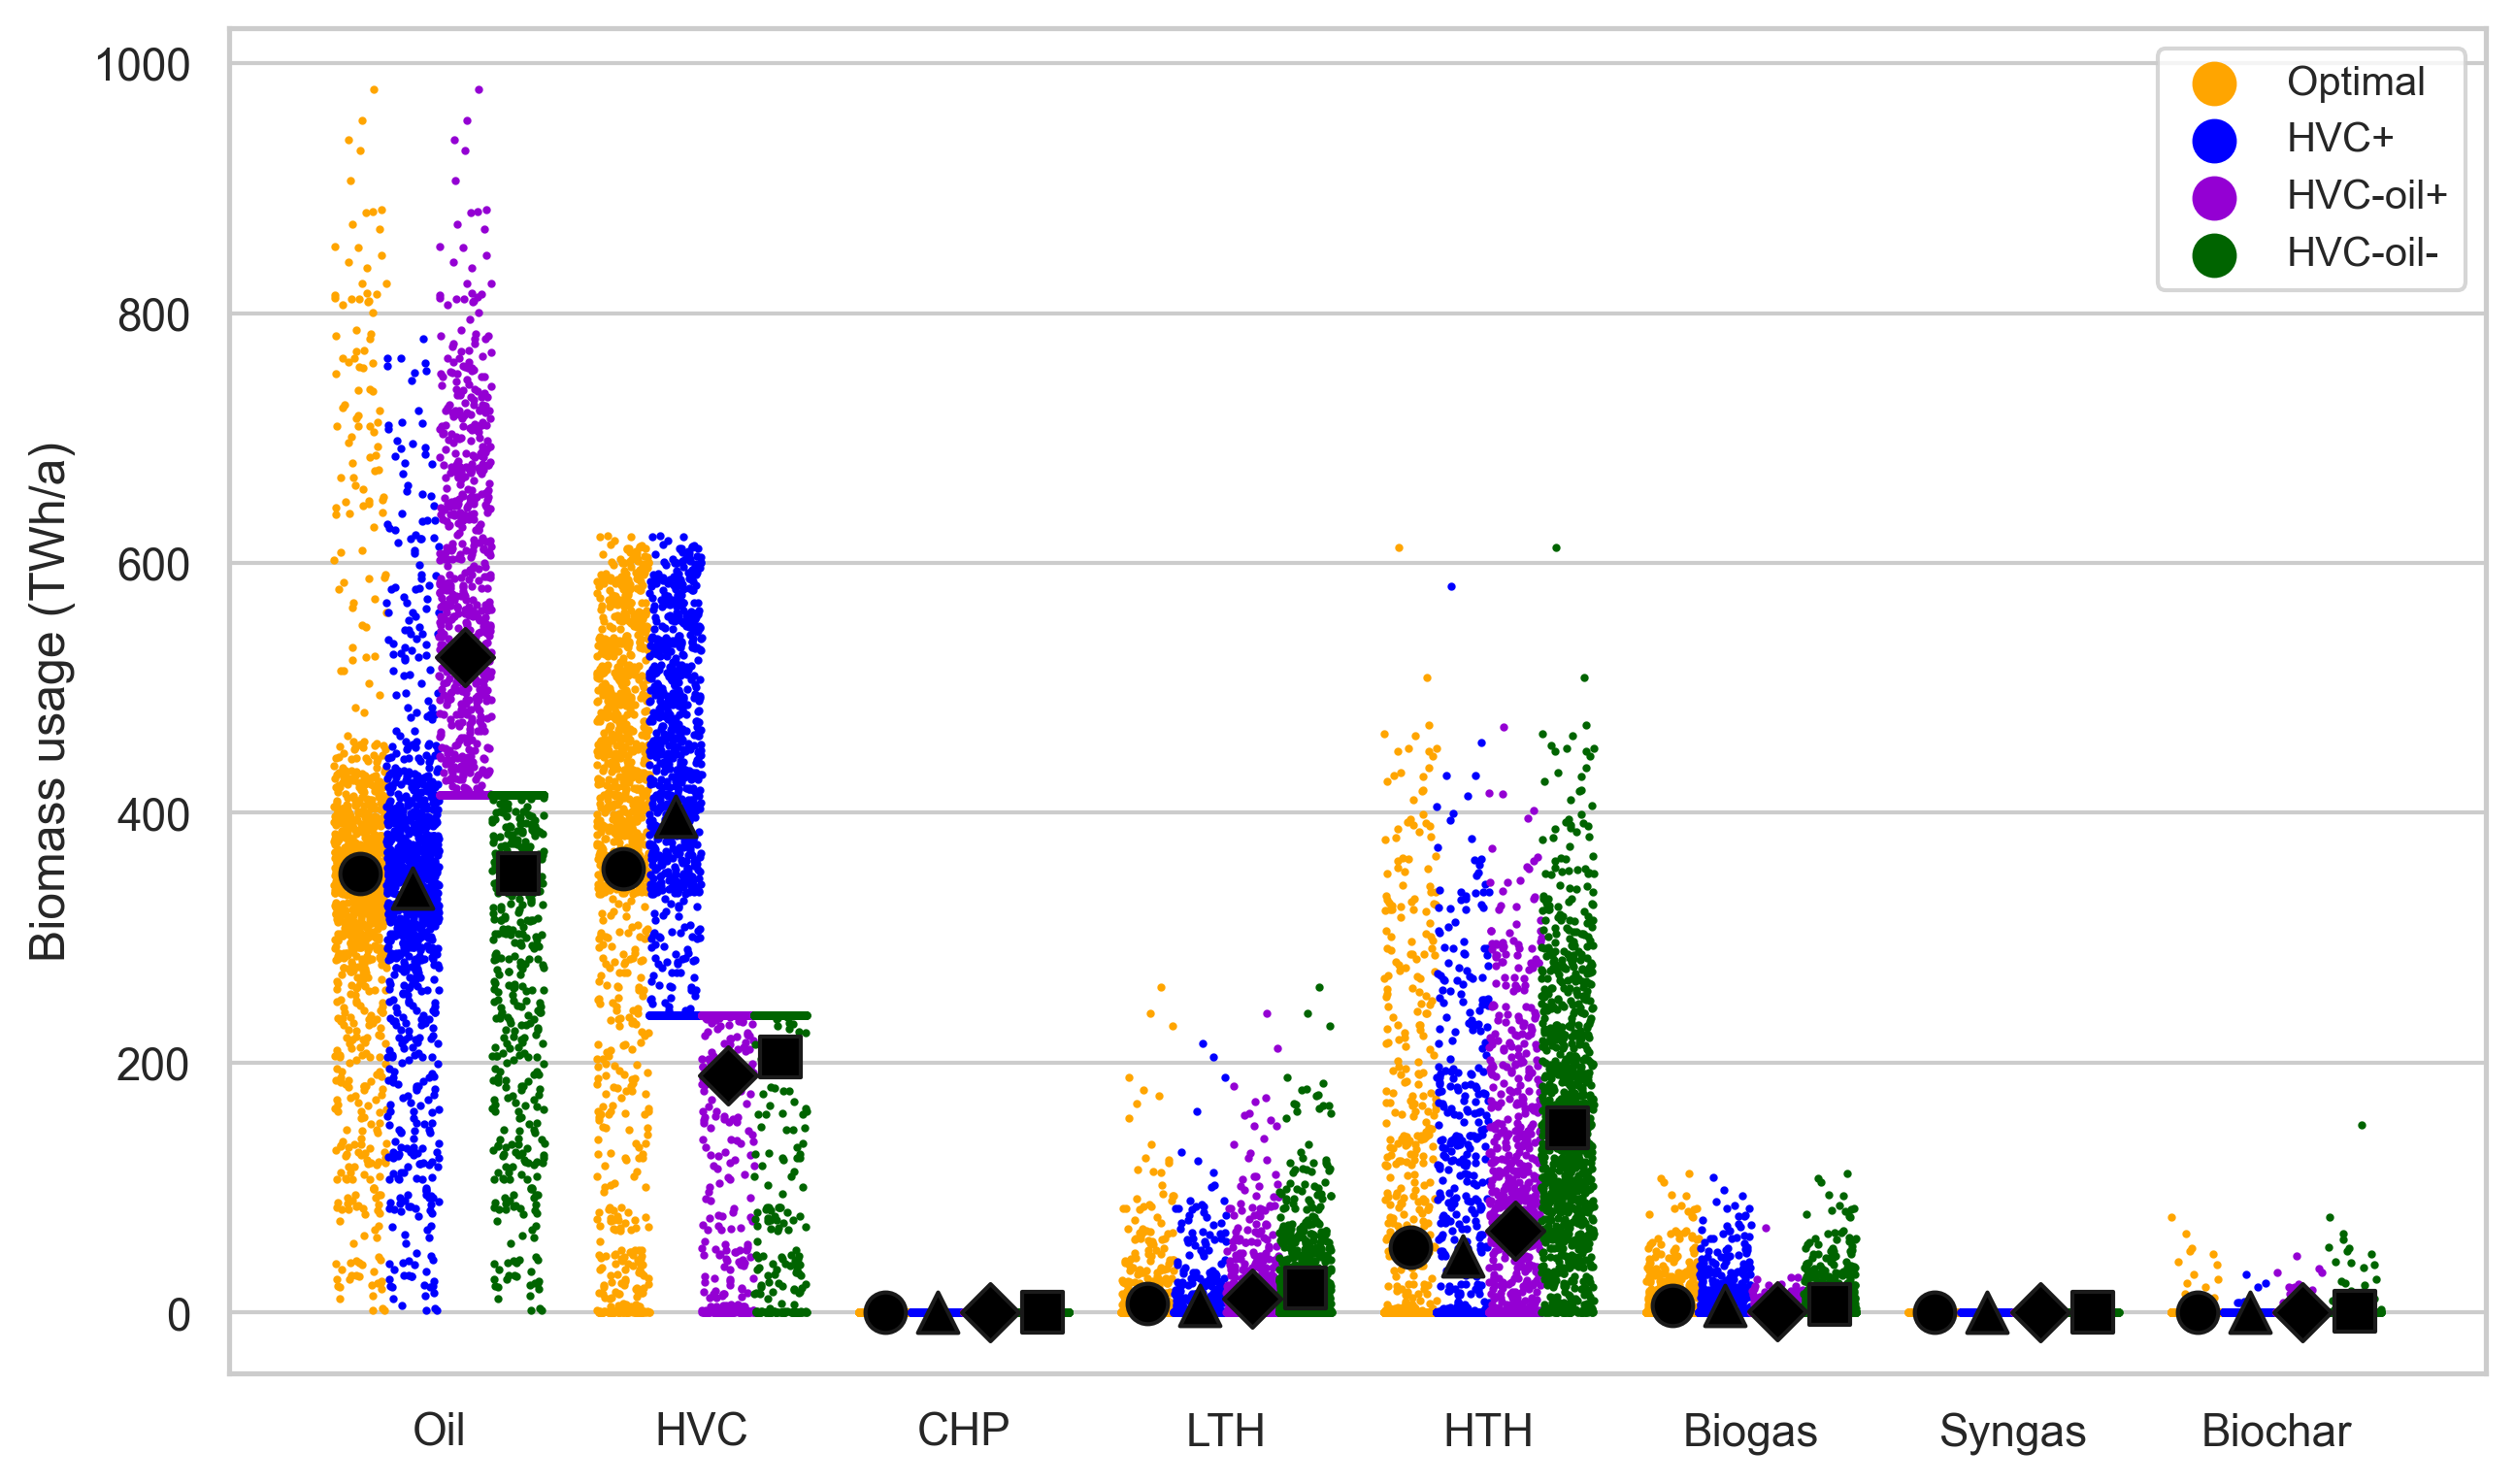

In [38]:
COLOR_MAP = {1: 'blue', 2: 'darkviolet', 0: 'darkgreen'}

# Randomness for jitter in scatter plots
randomness = np.random.random(len(df_output_of_interest_optimal))

# Define colors for the datasets
optimal_color = 'orange'
cluster_0_color = COLOR_MAP[0]
cluster_1_color = COLOR_MAP[1]
cluster_2_color = COLOR_MAP[2]

# Plot the data
plt.figure(figsize=(10, 6), dpi=300)

# Scatter plots for each category
for i, category in enumerate(df_output_of_interest_optimal.columns):
    # Optimal data scatter
    plt.scatter([i - 0.4] * len(df_output_of_interest_optimal) + 
                randomness * 0.2, 
                df_output_of_interest_optimal[category], 
                s=1, alpha=1, c=optimal_color, label='Optimal' if i == 0 else "")

    # Mean of optimal data
    mean_optimal = np.mean(df_output_of_interest_optimal[category])
    plt.scatter([i - 0.3], mean_optimal, s=100, c='black', edgecolor='k', zorder=5)

    # Cluster 1 data scatter
    plt.scatter([i - 0.2] * len(df_output_of_interest_cluster_1) + 
                randomness * 0.2, 
                df_output_of_interest_cluster_1[category], 
                s=1, alpha=1, c=cluster_1_color, label='HVC+' if i == 0 else "")

    # Mean of cluster 1 data
    mean_cluster_1 = np.mean(df_output_of_interest_cluster_1[category])
    plt.scatter([i - 0.1], mean_cluster_1, s=100, c='black', edgecolor='k', marker='^', zorder=5)

    # Cluster 2 data scatter
    plt.scatter([i + 0] * len(df_output_of_interest_cluster_2) + 
                randomness * 0.2, 
                df_output_of_interest_cluster_2[category], 
                s=1, alpha=1, c=cluster_2_color, label='HVC-oil+' if i == 0 else "")

    # Mean of cluster 2 data
    mean_cluster_2 = np.mean(df_output_of_interest_cluster_2[category])
    plt.scatter([i + 0.1], mean_cluster_2, s=100, c='black', edgecolor='k', marker='D', zorder=5)

    # Constraint data scatter (Cluster 0)
    plt.scatter([i + 0.2] * len(df_output_of_interest_cluster_0) + 
                randomness * 0.2, 
                df_output_of_interest_cluster_0[category], 
                s=1, alpha=1, c=cluster_0_color, label='HVC-oil-' if i == 0 else "")

    # Mean of constraint data (Cluster 0)
    mean_constraint = np.mean(df_output_of_interest_cluster_0[category])
    plt.scatter([i+0.3], mean_constraint, s=100, c='black', edgecolor='k', marker='s', zorder=5)

    # Lines connecting means
    # plt.plot([i - 0.3, i-0.1, i + 0.1, i + 0.3], [mean_optimal, mean_constraint, mean_cluster_1, mean_cluster_2], c='black', linestyle='-', linewidth=2)

# Set x-axis tick labels
plt.xticks(range(len(df_output_of_interest_optimal.columns)),  ['Oil', 'HVC', 'CHP', 'LTH', 'HTH', 'Biogas', 'Syngas', 'Biochar'], rotation=0)
# plt.xticks(range(len(df_output_of_interest_optimal.columns)),  df_output_of_interest_optimal.columns, rotation=0)

plt.xlim(-0.8, len(df_output_of_interest_optimal.columns) - 0.2)

# Set labels
plt.ylabel('Biomass usage (TWh/a)')
# plt.title('Biomass usage with strategies applied')

# Customize legend
plt.legend(scatterpoints=1, fontsize=10, markerscale=10)

# Only print horizontal grid lines
plt.grid(axis='x')

# Show the plot
plt.show()


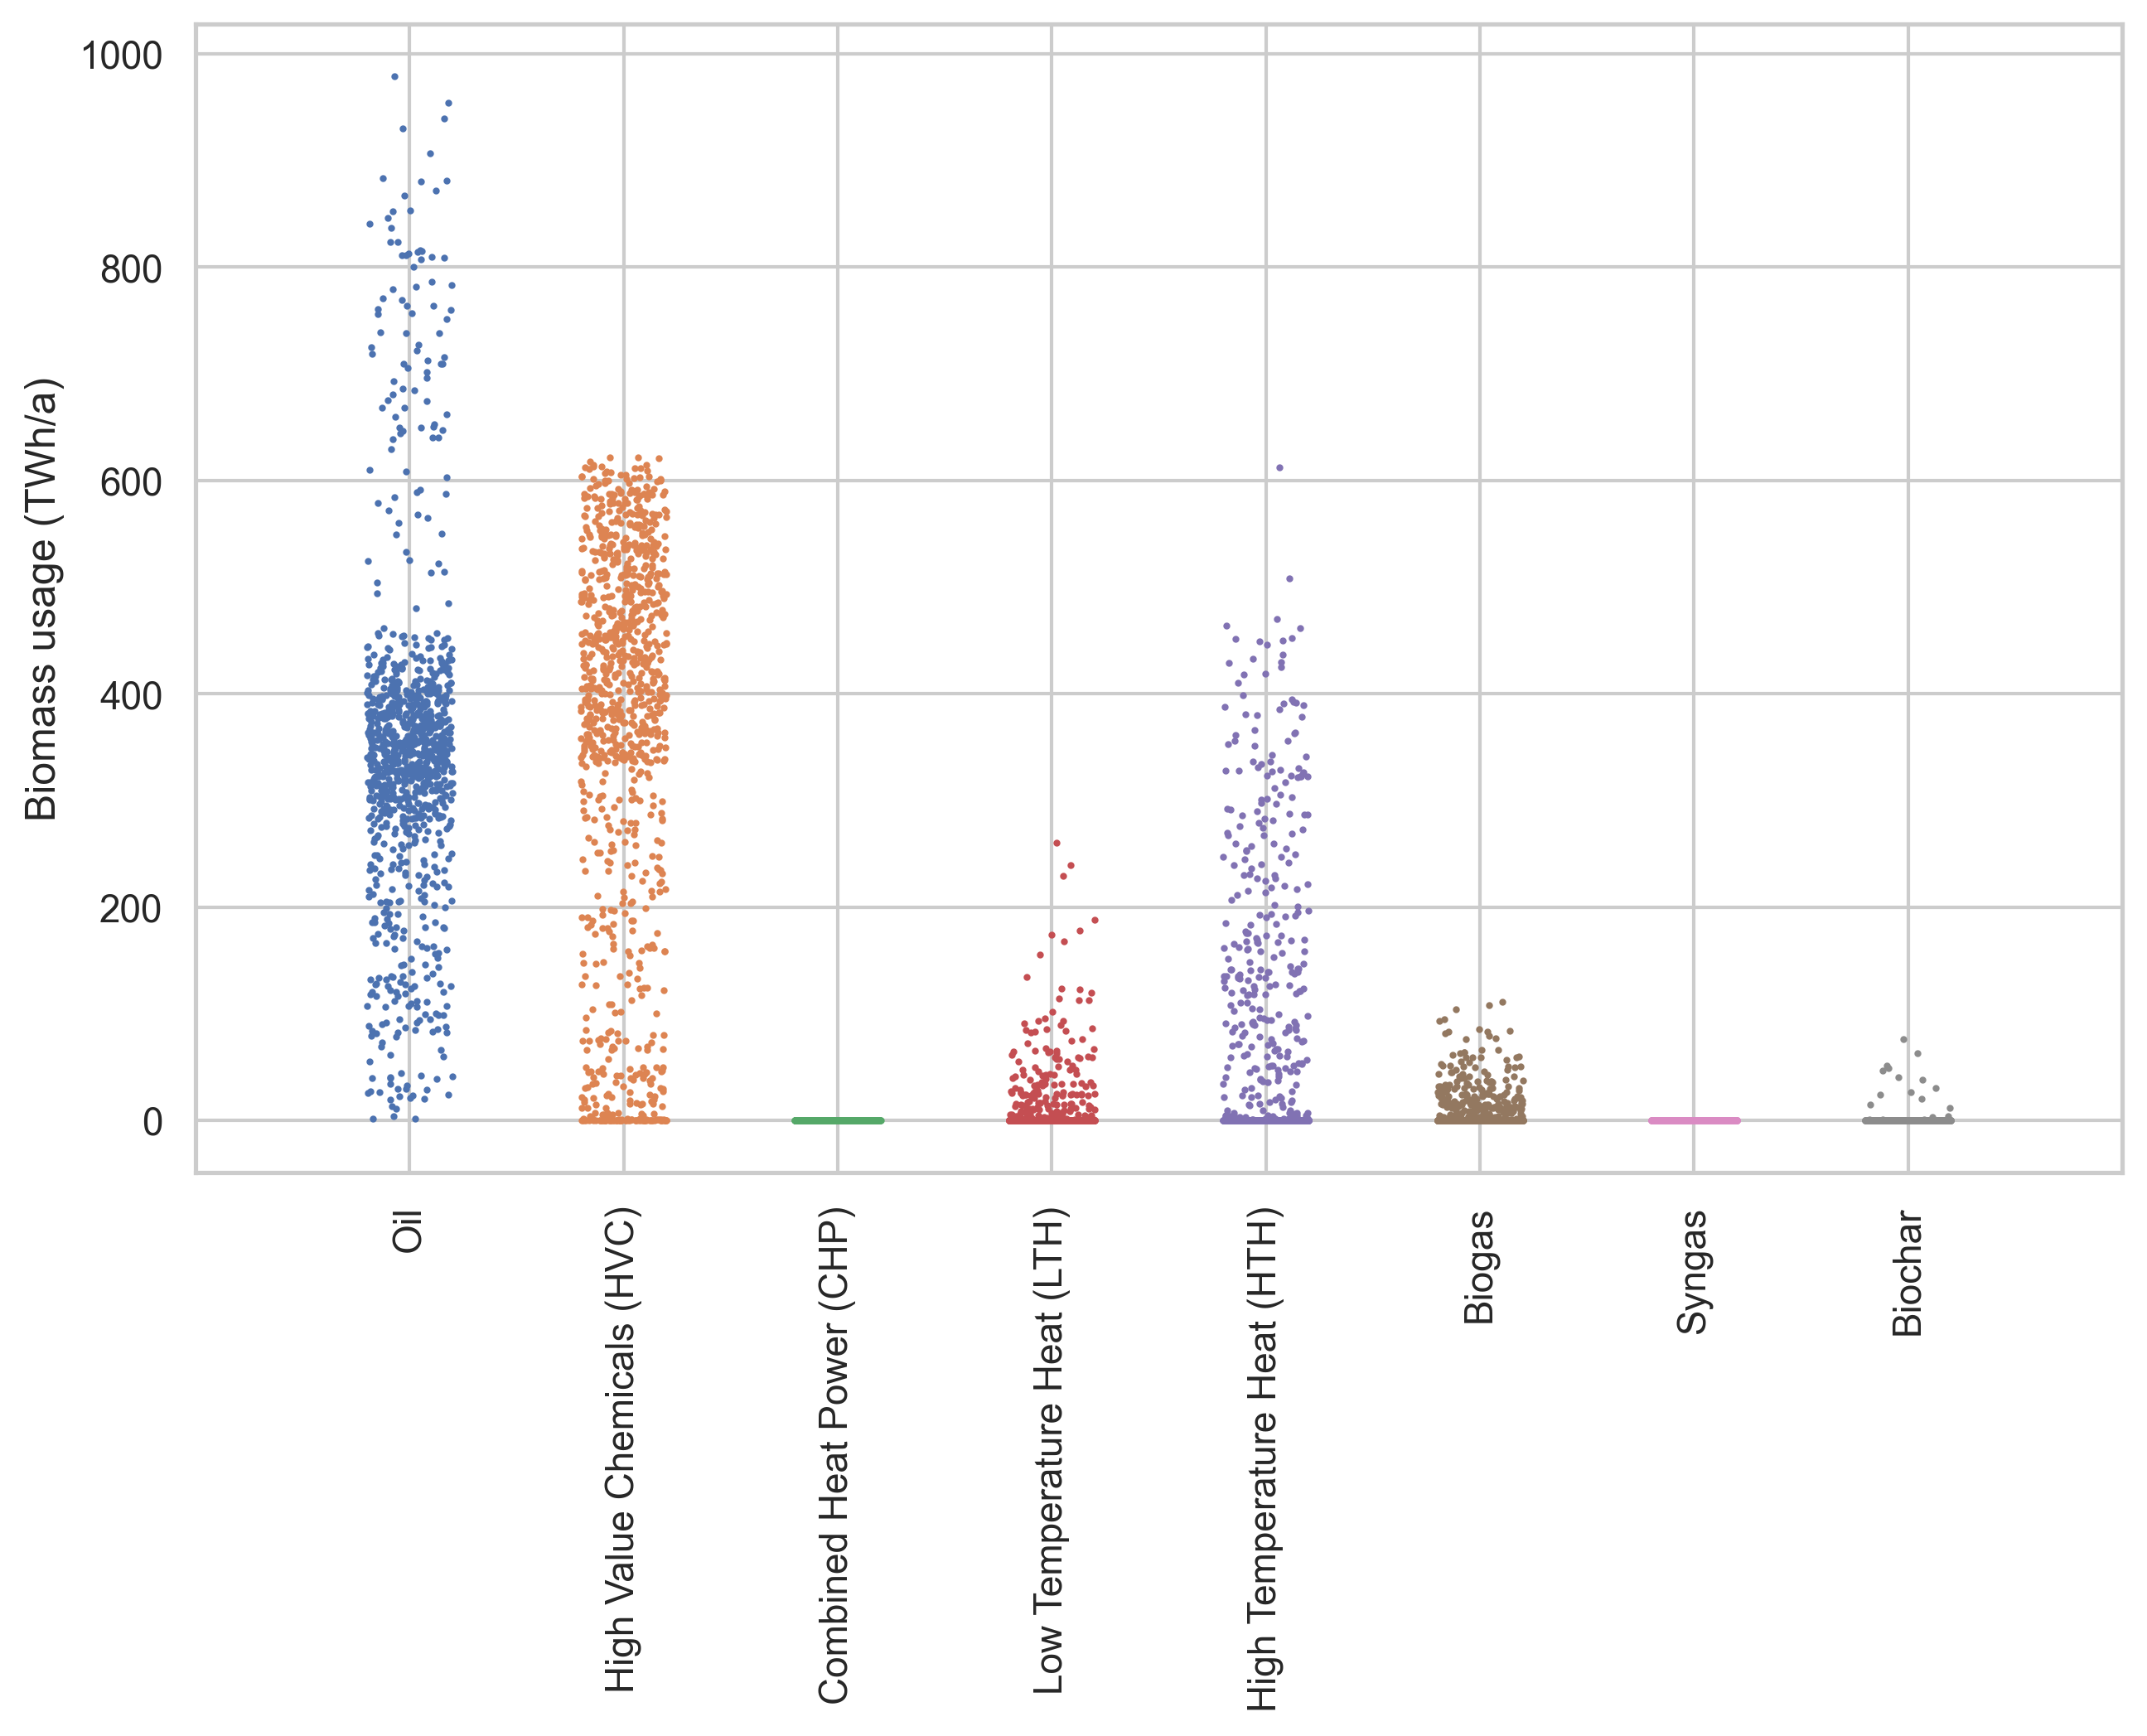

In [39]:


# Plot the dataframe
plt.figure(figsize=(10, 6), dpi=300)
for i, category in enumerate(df_output_of_interest_optimal.columns):
    plt.scatter([i-0.2]*len(df_output_of_interest_optimal)+np.random.random(len(df_output_of_interest_optimal),)*0.4, df_output_of_interest_optimal[category].abs(), s=1, )

# plt.scatter([0-0.1]*len(df_output_of_interest_optimal)+np.random.random(len(df_output_of_interest_optimal),)*0.2, df_output_of_interest_optimal[df_output_of_interest_optimal.columns[0]], s=1)


# Set the x-axis tick labels
plt.xticks(range(len(df_output_of_interest_optimal.columns)), ['Oil', 'High Value Chemicals (HVC)', 'Combined Heat Power (CHP)', 'Low Temperature Heat (LTH)', 'High Temperature Heat (HTH)', 'Biogas', 'Syngas', 'Biochar'], rotation=90)
# plt.xticks(range(len(df_output_of_interest_optimal.columns)), df_output_of_interest_optimal.columns, rotation=0)
plt.xlim(-1, len(df_output_of_interest_optimal.columns))

# Set labels
plt.ylabel('Biomass usage (TWh/a)')
# plt.xlabel('Category')


# Show the plot
plt.show()

In [40]:
path = "/home/gwiest/Test/LHS_sim4/"
figure_path = "/home/gwiest/Test/Figures/"
save=True
#nodes_dict = {0:2, 2:1, 1:3, 3:0}
nodes_dict = {0:0, 1:1, 2:2, 3:3, 4:4}
data = np.random.random((100,6))
#df = pd.DataFrame(data, columns=['FUEL','NG','H2','HTH','CHP','BIOCHAR'])
#df['final_cluster'] = np.random.randint(0,4,100)
#df = pd.DataFrame()
for i in range(5):
    print(i)
    df_i = pd.read_csv(path + "Leaf"+str(i)+"/results/outputs_of_interest.csv",sep=";")
    plt.figure()
    spread = 0.3*np.random.rand(len(df_i["LTH"]),1)
    df_i.drop(columns=["LTH","HTH","CHP"], inplace=True)
    for j,col in enumerate(df_i.columns[1:]):
        print(col)
        plt.scatter(j+spread+0.05, df_i[col], alpha=0.1,marker="s")
        plt.scatter(-0.35+j+0.3*np.random.rand(len(df[df["cluster_final"]==i]["FUEL"]),1), df[df["cluster_final"]==i][col],marker="o" ,alpha=0.1)
       
       
        # plot the means
        plt.scatter(j+0.2, np.mean(df_i[col]), c="k",marker="s")
        plt.scatter(-0.2+j, np.mean(df[df["cluster_final"]==i][col]), c="k",marker="o")
        # connect the means
        plt.plot([j+0.2,-0.2+j],[np.mean(df_i[col]),np.mean(df[df["cluster_final"]==i][col])], c="k", linewidth=1, linestyle='solid')
       
    plt.scatter(0,-1000,c="k",marker="o",label="Optimal scenarios", alpha=0.5)
    plt.scatter(0,-1000,c="k",marker="s",label="Regret scenarios", alpha=0.5)
    plt.ylim(bottom=0)
    plt.xticks(range(len(df_i.columns[1:])),df_i.columns[1:],rotation=0)
    plt.ylabel("Energy flow [TWh/year]")
    plt.legend()
    plt.show()
    df_i["cluster_final"] = i

0


FileNotFoundError: [Errno 2] No such file or directory: '/home/gwiest/Test/LHS_sim4/Leaf0/results/outputs_of_interest.csv'